# Attrition Prediction: Random Forest vs. SOTA LLMs vs. Jev

**Question:** given a table of past employees, which model best spots the ones about to leave, and what does each one cost in time and money?

**Contenders:** a Random Forest baseline, three mid-tier frontier LLMs (Claude Sonnet 5, GPT-6 Sol, Gemini 3.8 Flash), and Jev, TypeSafe's calibrated decision model. (A local gpt-oss 20B is wired in but left out; see section 8.)

**The rules every model plays by**

| Rule | Why |
|---|---|
| No model ever sees a real employee | The IBM HR dataset is in every LLM's training data. A generator learns from real data; everything downstream is synthetic. |
| Identical input for everyone | Same 10 binned features, same 825 context rows, same prompt bytes. The RF trains on exactly the rows the LLMs read. |
| One employee per call, no tools, provider-default reasoning | The honest single-prediction baseline. Nothing is tuned per model. |
| Nobody is told that missing a leaver costs more | Symmetric and neutral. The cost asymmetry only shows up in the scoring. |
| Headline metric: **F2** on the leaver class | Rewards catching leavers (recall) but still penalises flagging everyone. Accuracy is useless at a 16% base rate. |

**Sections:** 1 Setup, 2 Split, 3 Synthetic employees, 4 Binning, 5 Feature selection, 6 RF baselines, 7 Prompt, 8 Models, 9 Run, then a separate real-data test, caveats and the figures.

## 1. Setup and data

The CSV comes straight from Kaggle through `kagglehub` and is cached outside the repo, so no data file is ever committed. One seed drives every random step.

In [34]:
%pip install -q kagglehub pandas scikit-learn sdv matplotlib seaborn tiktoken typesafe-sdk anthropic openai google-genai ollama

import random
from pathlib import Path

import numpy as np
import pandas as pd
import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Pull straight from Kaggle; cached under ~/.cache/kagglehub, never lands in the repo
KAGGLE_SLUG = "pavansubhasht/ibm-hr-analytics-attrition-dataset"
data_dir = Path(kagglehub.dataset_download(KAGGLE_SLUG))
csv_path = next(data_dir.glob("*.csv"))
real_dataset = pd.read_csv(csv_path)

print(f"Loaded {csv_path.name}")
print(f"Shape: {real_dataset.shape}")
print(f"Attrition base rate: {(real_dataset['Attrition'] == 'Yes').mean():.1%}")

real_dataset.head()


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Loaded WA_Fn-UseC_-HR-Employee-Attrition.csv
Shape: (1470, 35)
Attrition base rate: 16.1%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Split the real data first

Order matters for leakage: split the **real** data (stratified on Attrition) before anything is fit. The generator only ever learns from the train split. The real holdout is reserved for one RF-only fidelity check and is never shown to an LLM.

In [2]:
from sklearn.model_selection import train_test_split

TARGET = "Attrition"

# Step (a): split REAL data first, stratified, before anything is fit.
# real_train -> fits the generator (next cell)
# real_test  -> never shown to any LLM; used ONLY for the RF train-on-synthetic/test-on-real fidelity check
real_dataset_train, real_dataset_test = train_test_split(
    real_dataset, test_size=0.2, stratify=real_dataset[TARGET], random_state=SEED
)
real_dataset_train = real_dataset_train.reset_index(drop=True)
real_dataset_test = real_dataset_test.reset_index(drop=True)

for name, df in [("real_dataset", real_dataset), ("real_dataset_train", real_dataset_train), ("real_dataset_test", real_dataset_test)]:
    n_yes = (df[TARGET] == "Yes").sum()
    print(f"{name:<11} n={len(df):>4}  leavers={n_yes:>3}  rate={n_yes / len(df):.1%}")

real_dataset n=1470  leavers=237  rate=16.1%
real_dataset_train n=1176  leavers=190  rate=16.2%
real_dataset_test n= 294  leavers= 47  rate=16.0%


## 3. Synthetic employees (the anti-contamination step)

A TVAE generator learns the joint distribution of the real **train** split, including how each feature relates to attrition, and then produces new employees who never existed.

Two things we learned the hard way:
- **SDV's defaults were badly undertrained** (~900 gradient steps). They collapsed whole columns to a single value and exaggerated others: everyone "Travel_Rarely", and OverTime implied 88% attrition. A smaller batch trained until the loss plateaus fixed both.
- **Longer training memorized less, not more.** Near-copies of real people fell from 12% to 7% between 1,000 and 3,000 epochs.

C:\Users\miste\AppData\Local\Programs\Python\Python313\Lib\site-packages\sdv\single_table\base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Loss: -16.78: 100%|██████████| 3000/3000 [13:29<00:00,  3.71it/s]


Generator fit on 1176 real train rows x 31 columns
categorical    19
numerical      12
Mean loss change, last 200 epochs vs the 200 before: -0.88  (near 0 = leveled off)


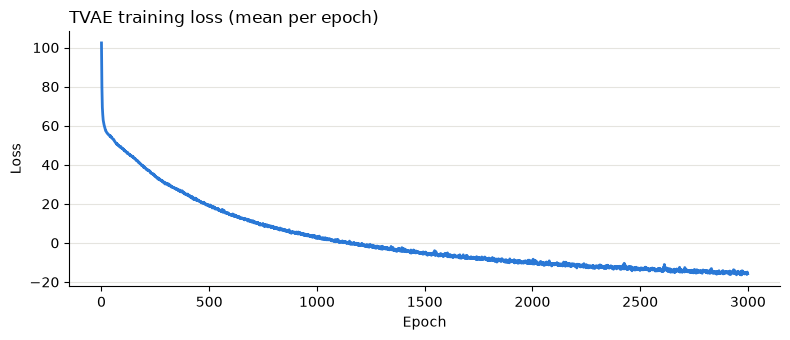

In [3]:
import torch
import matplotlib.pyplot as plt
from sdv.metadata import Metadata
from sdv.single_table import TVAESynthesizer

torch.manual_seed(SEED)

# Schema-only drop (no data-driven choice, so no leakage): constant columns + the ID column
CONSTANT_AND_ID_COLUMNS = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
real_dataset_train_pruned = real_dataset_train.drop(columns=CONSTANT_AND_ID_COLUMNS)
real_dataset_test_pruned = real_dataset_test.drop(columns=CONSTANT_AND_ID_COLUMNS)

# Step (b): fit the generator on the REAL TRAIN split only.
# SDV defaults (batch 500, 300 epochs) = ~900 gradient steps: badly undertrained, it collapsed
# BusinessTravel/WorkLifeBalance/TrainingTimes to one value. Batch 100 trained until the loss plateaus:
# epoch sweep showed loss flat by ~2500, category fidelity steady, and near-copies falling (12% -> 7%).
TVAE_EPOCHS = 3000
TVAE_BATCH_SIZE = 100
tvae_metadata = Metadata.detect_from_dataframe(data=real_dataset_train_pruned, table_name="employees")
tvae_generator = TVAESynthesizer(tvae_metadata, epochs=TVAE_EPOCHS, batch_size=TVAE_BATCH_SIZE, verbose=True)
tvae_generator.fit(real_dataset_train_pruned)

detected_column_types = pd.Series({
    column: spec["sdtype"]
    for column, spec in tvae_metadata.to_dict()["tables"]["employees"]["columns"].items()
})
print(f"\nGenerator fit on {len(real_dataset_train_pruned)} real train rows x {real_dataset_train_pruned.shape[1]} columns")
print(detected_column_types.value_counts().to_string())

# Training curve: has learning leveled off? Loss goes negative (it includes a log-likelihood term),
# so compare the absolute change between the last two 200-epoch windows.
loss_per_epoch = tvae_generator.get_loss_values().groupby("Epoch")["Loss"].mean()
late_window_change = loss_per_epoch.iloc[-200:].mean() - loss_per_epoch.iloc[-400:-200].mean()
print(f"Mean loss change, last 200 epochs vs the 200 before: {late_window_change:+.2f}  (near 0 = leveled off)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(loss_per_epoch.index, loss_per_epoch.values, color="#2a78d6", linewidth=2)
ax.set_title("TVAE training loss (mean per epoch)", loc="left")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(axis="y", color="#e5e4df", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Sampling

Sampling freely first is a diagnostic: does the generator reproduce the real ~16% leaver rate on its own? The pools are oversized because the next steps filter rows out.

In [16]:
from sdv.sampling import Condition

# Step (c): sample OVERSIZED pools. The near-copy filter drops a chunk of rows,
# then each pool is trimmed to its final size.
SYNTHETIC_TRAIN_SIZE = len(real_dataset_train_pruned)   # 1176, same as real train
SYNTHETIC_TEST_LEAVERS = 16
SYNTHETIC_TEST_STAYERS = 84
TRAIN_POOL_HEADROOM = 3
TEST_POOL_HEADROOM = 5

# SDV's sampler keeps advancing between calls, so re-running this cell alone would draw DIFFERENT employees.
# Reset to the post-fit state so every run of cells 4-6 produces the same synthetic datasets.
tvae_generator.reset_sampling()

# Train pool: sampled FREELY, so the leaver rate is whatever TVAE learned (a generator sanity check)
synthetic_train_pool = tvae_generator.sample(num_rows=int(SYNTHETIC_TRAIN_SIZE * TRAIN_POOL_HEADROOM))

# Test pool: conditioned on Attrition so the final test set can be exactly 16 leavers / 84 stayers
synthetic_test_pool = tvae_generator.sample_from_conditions([
    Condition(num_rows=SYNTHETIC_TEST_LEAVERS * TEST_POOL_HEADROOM, column_values={TARGET: "Yes"}),
    Condition(num_rows=SYNTHETIC_TEST_STAYERS * TEST_POOL_HEADROOM, column_values={TARGET: "No"}),
])

real_train_leaver_rate = (real_dataset_train_pruned[TARGET] == "Yes").mean()
synthetic_train_leaver_rate = (synthetic_train_pool[TARGET] == "Yes").mean()
print(f"synthetic_train_pool  n={len(synthetic_train_pool)}  leaver rate={synthetic_train_leaver_rate:.1%}  (real train: {real_train_leaver_rate:.1%})")
print(f"synthetic_test_pool   n={len(synthetic_test_pool)}  {synthetic_test_pool[TARGET].value_counts().to_dict()}")

# Generator fidelity on the free pool: did any category vanish, and how far off are the category shares?
generator_check_columns = [column for column in detected_column_types[detected_column_types == "categorical"].index if column != TARGET]
missing_categories = {
    column: sorted(set(real_dataset_train_pruned[column].astype(str)) - set(synthetic_train_pool[column].astype(str)))
    for column in generator_check_columns
}
missing_categories = {column: values for column, values in missing_categories.items() if values}
share_gap_per_column = pd.Series({   # total variation distance: 0 = identical shares, 1 = no overlap
    column: 0.5 * real_dataset_train_pruned[column].astype(str).value_counts(normalize=True)
        .subtract(synthetic_train_pool[column].astype(str).value_counts(normalize=True), fill_value=0).abs().sum()
    for column in generator_check_columns
})
print(f"\nCategories missing from synthetic: {missing_categories or 'none'}")
print(f"Category share gap (TVD), mean over {len(generator_check_columns)} columns: {share_gap_per_column.mean():.3f}   worst: {share_gap_per_column.idxmax()} {share_gap_per_column.max():.3f}")
for label, df in [("real train", real_dataset_train_pruned), ("synthetic", synthetic_train_pool)]:
    leave_rate_by_overtime = df.groupby("OverTime")[TARGET].apply(lambda s: (s == "Yes").mean())
    print(f"Leave rate by OverTime, {label:<10}: No={leave_rate_by_overtime['No']:.2f}  Yes={leave_rate_by_overtime['Yes']:.2f}")

Sampling conditions: 100%|██████████| 500/500 [00:00<00:00, 695.85it/s] 

synthetic_train_pool  n=3528  leaver rate=18.9%  (real train: 16.2%)
synthetic_test_pool   n=500  {'No': 420, 'Yes': 80}

Categories missing from synthetic: none
Category share gap (TVD), mean over 18 columns: 0.055   worst: JobRole 0.263
Leave rate by OverTime, real train: No=0.11  Yes=0.29
Leave rate by OverTime, synthetic : No=0.16  Yes=0.28


### Locking the base rate

The final train set is conditioned to the real train leaver rate (16.2%) and the test set to exactly **16 leavers / 84 stayers**, so no model gets lucky or unlucky with class drift.

In [17]:
# Option A: condition the train pool to the REAL train leaver rate, so the base rate is exact rather than
# whatever TVAE drifts to (the undertrained generator gave 5.6%). The previous cell's free pool is diagnostic only.
SYNTHETIC_TRAIN_LEAVERS = round(SYNTHETIC_TRAIN_SIZE * real_train_leaver_rate)   # 190
SYNTHETIC_TRAIN_STAYERS = SYNTHETIC_TRAIN_SIZE - SYNTHETIC_TRAIN_LEAVERS           # 986

requested_train_pool_counts = {
    "Yes": SYNTHETIC_TRAIN_LEAVERS * TRAIN_POOL_HEADROOM,
    "No": SYNTHETIC_TRAIN_STAYERS * TRAIN_POOL_HEADROOM,
}

# Conditional sampling is rejection sampling: if TVAE rarely emits a class, it needs many tries.
# At the default (100) it can return fewer rows than requested with only a warning.
synthetic_train_pool_conditioned = tvae_generator.sample_from_conditions(
    [Condition(num_rows=count, column_values={TARGET: label}) for label, count in requested_train_pool_counts.items()],
    max_tries_per_batch=1000,
)

requested_test_pool_counts = {
    "Yes": SYNTHETIC_TEST_LEAVERS * TEST_POOL_HEADROOM,
    "No": SYNTHETIC_TEST_STAYERS * TEST_POOL_HEADROOM,
}
for pool_name, pool, requested_counts in [
    ("synthetic_train_pool_conditioned", synthetic_train_pool_conditioned, requested_train_pool_counts),
    ("synthetic_test_pool", synthetic_test_pool, requested_test_pool_counts),
]:
    actual_counts = pool[TARGET].value_counts().to_dict()
    assert actual_counts == requested_counts, f"{pool_name}: got {actual_counts}, requested {requested_counts}"
    print(f"{pool_name:<33} n={len(pool):>4}  {actual_counts}  leaver rate={actual_counts['Yes'] / len(pool):.1%}")

Sampling conditions: 100%|██████████| 3528/3528 [00:01<00:00, 3207.46it/s] 

synthetic_train_pool_conditioned  n=3528  {'No': 2958, 'Yes': 570}  leaver rate=16.2%
synthetic_test_pool               n= 500  {'No': 420, 'Yes': 80}  leaver rate=16.0%


### No near-copies of real people

A synthetic row that almost duplicates a real employee would reintroduce the contamination we're avoiding. Rule: drop any synthetic employee who sits closer to a real employee than **95% of real strangers do** (real holdout vs real train). Synthetic test rows that duplicate a synthetic train row are dropped too.

In [18]:
from sklearn.neighbors import NearestNeighbors

# Near-copy filter (#2): no synthetic employee may sit closer to a real employee than real strangers do.
# Distance uses FEATURES only; a copied person is recognizable regardless of their label.
feature_columns = [column for column in real_dataset_train_pruned.columns if column != TARGET]
categorical_feature_columns = [column for column in feature_columns if detected_column_types[column] == "categorical"]
numerical_feature_columns = [column for column in feature_columns if detected_column_types[column] == "numerical"]

# Scaling and one-hot vocabulary come from REAL TRAIN, the set we're protecting
numerical_min = real_dataset_train_pruned[numerical_feature_columns].min()
numerical_range = real_dataset_train_pruned[numerical_feature_columns].max() - numerical_min

def encode_for_distance(df):
    scaled_numericals = (df[numerical_feature_columns] - numerical_min) / numerical_range
    one_hot_categoricals = pd.get_dummies(df[categorical_feature_columns].astype(str))
    return pd.concat([scaled_numericals, one_hot_categoricals], axis=1)

real_train_encoded = encode_for_distance(real_dataset_train_pruned).astype(float)
closest_real_employee_finder = NearestNeighbors(n_neighbors=1).fit(real_train_encoded.values)

def distance_to_closest_real_employee(df):
    encoded = encode_for_distance(df).reindex(columns=real_train_encoded.columns, fill_value=0).astype(float)
    return closest_real_employee_finder.kneighbors(encoded.values)[0][:, 0]

# Threshold = how close real STRANGERS (real holdout) naturally sit to real train employees.
# real_dataset_test only sets this number; no model sees it.
NEAR_COPY_PERCENTILE = 5
real_stranger_distances = distance_to_closest_real_employee(real_dataset_test_pruned)
near_copy_threshold = np.percentile(real_stranger_distances, NEAR_COPY_PERCENTILE)

def drop_near_copies(pool):
    return pool[distance_to_closest_real_employee(pool) >= near_copy_threshold]

def take_exact_counts(pool, counts_by_label, pool_name):
    parts = []
    for label, count in counts_by_label.items():
        available = pool[pool[TARGET] == label]
        assert len(available) >= count, f"{pool_name}: only {len(available)} '{label}' rows survived the filter, need {count}. Raise the pool headroom."
        parts.append(available.sample(n=count, random_state=SEED))
    return pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)   # shuffle so classes aren't grouped

# Final synthetic TRAIN
synthetic_train_pool_filtered = drop_near_copies(synthetic_train_pool_conditioned.drop_duplicates())
synthetic_dataset_train = take_exact_counts(
    synthetic_train_pool_filtered, {"Yes": SYNTHETIC_TRAIN_LEAVERS, "No": SYNTHETIC_TRAIN_STAYERS}, "train pool"
)

# Final synthetic TEST: also drop any row whose features exactly match a synthetic TRAIN row (train/test overlap)
synthetic_test_pool_filtered = drop_near_copies(synthetic_test_pool.drop_duplicates())
synthetic_train_feature_rows = set(map(tuple, synthetic_dataset_train[feature_columns].astype(str).values))
overlaps_synthetic_train = synthetic_test_pool_filtered[feature_columns].astype(str).apply(tuple, axis=1).isin(synthetic_train_feature_rows)
synthetic_test_pool_filtered = synthetic_test_pool_filtered[~overlaps_synthetic_train]
synthetic_dataset_test = take_exact_counts(
    synthetic_test_pool_filtered, {"Yes": SYNTHETIC_TEST_LEAVERS, "No": SYNTHETIC_TEST_STAYERS}, "test pool"
)

print(f"Near-copy threshold (p{NEAR_COPY_PERCENTILE} of real-stranger distances): {near_copy_threshold:.3f}")
print(f"Median distance to closest real employee: real strangers={np.median(real_stranger_distances):.3f}  "
      f"synthetic train={np.median(distance_to_closest_real_employee(synthetic_dataset_train)):.3f}")
for pool_name, pool_before, pool_after in [
    ("train pool", synthetic_train_pool_conditioned, synthetic_train_pool_filtered),
    ("test pool", synthetic_test_pool, synthetic_test_pool_filtered),
]:
    print(f"{pool_name:<11} before={pool_before[TARGET].value_counts().to_dict()}  after={pool_after[TARGET].value_counts().to_dict()}")
print(f"test rows dropped as exact synthetic-train overlaps: {overlaps_synthetic_train.sum()}")
for dataset_name, dataset in [("synthetic_dataset_train", synthetic_dataset_train), ("synthetic_dataset_test", synthetic_dataset_test)]:
    print(f"{dataset_name:<24} n={len(dataset):>4}  {dataset[TARGET].value_counts().to_dict()}  leaver rate={(dataset[TARGET] == 'Yes').mean():.1%}")

Near-copy threshold (p5 of real-stranger distances): 2.591
Median distance to closest real employee: real strangers=3.254  synthetic train=3.235
train pool  before={'No': 2958, 'Yes': 570}  after={'No': 2739, 'Yes': 541}
test pool   before={'No': 420, 'Yes': 80}  after={'No': 387, 'Yes': 73}
test rows dropped as exact synthetic-train overlaps: 0
synthetic_dataset_train  n=1176  {'No': 986, 'Yes': 190}  leaver rate=16.2%
synthetic_dataset_test   n= 100  {'No': 84, 'Yes': 16}  leaver rate=16.0%


## 4. Bin everything into labelled categories

LLMs are unreliable at arithmetic over raw numbers, and the RF must see the same representation for fairness. So every feature becomes a readable category: ages in three bands, money and tenure in quartile bands, and 1-4 codes mapped to their data-dictionary labels ("Low" ... "Very High"). All data-driven bin edges come from **synthetic train only**.

In [19]:
# Step 3: bin EVERYTHING to labeled categories. Every model (RF included) sees only this representation.
# Data-driven bin edges come from SYNTHETIC TRAIN only, then are applied unchanged to every other set.

# Fixed domain bins (no data involved)
AGE_BINS = {"edges": [-np.inf, 30, 40, np.inf], "labels": ["<30", "30-39", "40+"]}
NUM_COMPANIES_WORKED_BINS = {"edges": [-np.inf, 2, 5, np.inf], "labels": ["0-1", "2-4", "5+"]}
TRAINING_TIMES_LAST_YEAR_BINS = {"edges": [-np.inf, 2, 4, np.inf], "labels": ["0-1", "2-3", "4+"]}
FIXED_BINS = {
    "Age": AGE_BINS,
    "NumCompaniesWorked": NUM_COMPANIES_WORKED_BINS,
    "TrainingTimesLastYear": TRAINING_TIMES_LAST_YEAR_BINS,
}

# Ordinal codes -> the labels from the IBM data dictionary
LOW_TO_VERY_HIGH = {1: "Low", 2: "Medium", 3: "High", 4: "Very High"}
ORDINAL_LABELS = {
    "Education": {1: "Below College", 2: "College", 3: "Bachelor", 4: "Master", 5: "Doctor"},
    "EnvironmentSatisfaction": LOW_TO_VERY_HIGH,
    "JobInvolvement": LOW_TO_VERY_HIGH,
    "JobSatisfaction": LOW_TO_VERY_HIGH,
    "RelationshipSatisfaction": LOW_TO_VERY_HIGH,
    "WorkLifeBalance": {1: "Bad", 2: "Good", 3: "Better", 4: "Best"},
    "PerformanceRating": {1: "Low", 2: "Good", 3: "Excellent", 4: "Outstanding"},
}

# Money and tenure -> quartile bands, edges fit on synthetic train
QUARTILE_COLUMNS = [
    "DailyRate", "HourlyRate", "MonthlyRate", "MonthlyIncome", "PercentSalaryHike", "DistanceFromHome",
    "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager",
]

def quartile_band_labels(edges):
    # Integer-valued columns, bins are (low, high]: label each as a readable integer range
    labels = []
    for band_index, (low, high) in enumerate(zip(edges[:-1], edges[1:])):
        if band_index == 0:
            labels.append(f"<= {int(high):,}")
        elif band_index == len(edges) - 2:
            labels.append(f"> {int(low):,}")
        elif int(low) + 1 == int(high):
            labels.append(f"{int(high):,}")   # single-value band, e.g. exactly 3 years
        else:
            labels.append(f"{int(low) + 1:,}-{int(high):,}")
    return labels

quartile_bins = {}
for column in QUARTILE_COLUMNS:
    _, edges = pd.qcut(synthetic_dataset_train[column], q=4, retbins=True, duplicates="drop")   # skewed columns may get < 4 bands
    edges[0], edges[-1] = -np.inf, np.inf   # open-ended so unseen extremes in other sets still land in a band
    quartile_bins[column] = {"edges": edges, "labels": quartile_band_labels(edges)}

def bin_employees(df):
    binned = pd.DataFrame(index=df.index)
    for column in feature_columns:
        if column in FIXED_BINS:
            spec = FIXED_BINS[column]
            binned[column] = pd.cut(df[column], bins=spec["edges"], labels=spec["labels"], right=False).astype(str)
        elif column in quartile_bins:
            spec = quartile_bins[column]
            binned[column] = pd.cut(df[column], bins=spec["edges"], labels=spec["labels"]).astype(str)
        elif column in ORDINAL_LABELS:
            binned[column] = df[column].astype(int).map(ORDINAL_LABELS[column])
        else:
            binned[column] = df[column].astype(str)   # already categorical: Department, JobRole, OverTime, JobLevel, ...
    binned[TARGET] = df[TARGET].values
    assert not binned.isna().any().any(), "a value fell outside its bin or label map"
    return binned

synthetic_dataset_train_binned = bin_employees(synthetic_dataset_train)
synthetic_dataset_test_binned = bin_employees(synthetic_dataset_test)
real_dataset_test_binned = bin_employees(real_dataset_test_pruned)   # RF fidelity check (#1) only, never an LLM

# Every test category must exist in train, or the RF / prompt would meet a value it never saw
for dataset_name, dataset in [("synthetic_dataset_test_binned", synthetic_dataset_test_binned), ("real_dataset_test_binned", real_dataset_test_binned)]:
    unseen = {column: sorted(set(dataset[column]) - set(synthetic_dataset_train_binned[column])) for column in feature_columns}
    unseen = {column: values for column, values in unseen.items() if values}
    print(f"{dataset_name}: unseen categories = {unseen or 'none'}")

print("\nQuartile bands (edges from synthetic train):")
for column, spec in quartile_bins.items():
    print(f"  {column:<24} {spec['labels']}")
synthetic_dataset_train_binned.head()

synthetic_dataset_test_binned: unseen categories = none
real_dataset_test_binned: unseen categories = none

Quartile bands (edges from synthetic train):
  DailyRate                ['<= 430', '431-756', '757-1,119', '> 1,119']
  HourlyRate               ['<= 45', '46-62', '63-80', '> 80']
  MonthlyRate              ['<= 8,960', '8,961-15,157', '15,158-21,098', '> 21,098']
  MonthlyIncome            ['<= 3,570', '3,571-5,250', '5,251-8,548', '> 8,548']
  PercentSalaryHike        ['<= 12', '13-14', '15-18', '> 18']
  DistanceFromHome         ['<= 3', '4-8', '9-18', '> 18']
  TotalWorkingYears        ['<= 6', '7-10', '11-15', '> 15']
  YearsAtCompany           ['<= 4', '5-6', '7-9', '> 9']
  YearsInCurrentRole       ['<= 2', '3', '4-7', '> 7']
  YearsSinceLastPromotion  ['<= 1', '2', '> 2']
  YearsWithCurrManager     ['<= 2', '3', '4-7', '> 7']


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,<30,Travel_Rarely,"757-1,119",Human Resources,<= 3,Below College,Medical,Very High,Female,63-80,...,Low,0,<= 6,0-1,Better,5-6,<= 2,<= 1,4-7,Yes
1,40+,Non-Travel,"> 1,119",Research & Development,> 18,College,Medical,High,Female,46-62,...,High,1,> 15,4+,Better,> 9,> 7,> 2,> 7,No
2,30-39,Travel_Frequently,"> 1,119",Sales,<= 3,Below College,Life Sciences,High,Male,63-80,...,Very High,0,7-10,0-1,Good,7-9,> 7,> 2,> 7,Yes
3,40+,Travel_Rarely,"> 1,119",Research & Development,> 18,Master,Technical Degree,Low,Male,<= 45,...,Medium,1,7-10,2-3,Better,5-6,<= 2,<= 1,<= 2,No
4,<30,Travel_Rarely,"> 1,119",Research & Development,9-18,College,Life Sciences,Low,Male,<= 45,...,Low,1,11-15,2-3,Better,> 9,> 7,> 2,4-7,No


## 5. Feature selection

The final prompt has to fit Jev's 32k-token input limit, the tightest constraint in the experiment, so the feature list is pruned hard. Features are ranked by **mutual information with Attrition** (model-agnostic, so it doesn't favour the RF), minus the score a shuffled target gets by chance.

In [20]:
from sklearn.metrics import mutual_info_score

# Step 2a: rank features by how strongly they're linked to Attrition, on SYNTHETIC TRAIN only (test never touched).
# Mutual information works on categories directly. Features with more categories score a little higher by
# chance alone, so subtract the average MI against a shuffled target (the chance level).
CHANCE_SHUFFLES = 200
shuffle_rng = np.random.default_rng(SEED)
attrition_labels = synthetic_dataset_train_binned[TARGET].values

feature_ranking = []
for column in feature_columns:
    observed_mi = mutual_info_score(synthetic_dataset_train_binned[column], attrition_labels)
    chance_mi = np.mean([
        mutual_info_score(synthetic_dataset_train_binned[column], shuffle_rng.permutation(attrition_labels))
        for _ in range(CHANCE_SHUFFLES)
    ])
    leave_rate_by_category = synthetic_dataset_train_binned.groupby(column)[TARGET].agg(lambda s: (s == "Yes").mean())
    employees_by_category = synthetic_dataset_train_binned[column].value_counts()
    riskiest_category = leave_rate_by_category.idxmax()
    feature_ranking.append({
        "feature": column,
        "mi_above_chance": observed_mi - chance_mi,
        "n_categories": len(employees_by_category),
        "riskiest_category": f"{riskiest_category}: {leave_rate_by_category.max():.0%} leave (n={employees_by_category[riskiest_category]})",
    })

feature_ranking = pd.DataFrame(feature_ranking).sort_values("mi_above_chance", ascending=False).reset_index(drop=True)
feature_ranking.index += 1
print(f"Base leave rate: {(attrition_labels == 'Yes').mean():.0%}")
feature_ranking.round({"mi_above_chance": 4})

Base leave rate: 16%


,feature,mi_above_chance,n_categories,riskiest_category
1,JobRole,0.0274,9,Human Resources: 41% leave (n=22)
2,WorkLifeBalance,0.0224,4,Bad: 41% leave (n=110)
3,EducationField,0.0191,6,Human Resources: 40% leave (n=35)
4,JobLevel,0.0172,5,1: 24% leave (n=420)
5,OverTime,0.0153,2,Yes: 28% leave (n=308)
6,BusinessTravel,0.0151,3,Travel_Frequently: 29% leave (n=252)
7,YearsAtCompany,0.0145,4,<= 4: 25% leave (n=396)
8,Department,0.0125,3,Human Resources: 38% leave (n=52)
9,MonthlyIncome,0.0122,4,"3,571-5,250: 22% leave (n=294)"
10,Education,0.0121,5,Bachelor: 22% leave (n=399)


### Redundancy

Two features that say the same thing waste prompt tokens. Cramér's V (the categorical version of a correlation) flags the overlapping pairs; from each pair at 0.5 or above we keep the higher-ranked feature.

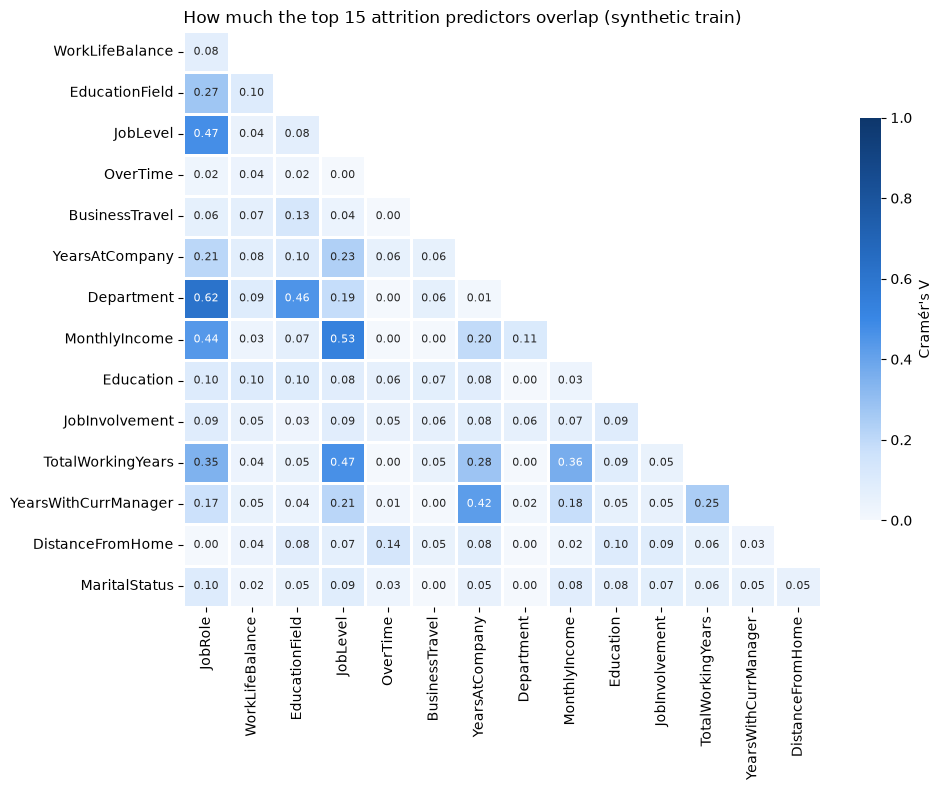

,feature_a,rank_a,feature_b,rank_b,cramers_v,redundant
0,JobRole,1,Department,8,0.62,True
1,JobLevel,4,MonthlyIncome,9,0.53,True
2,JobRole,1,JobLevel,4,0.47,False
3,JobLevel,4,TotalWorkingYears,12,0.47,False
4,EducationField,3,Department,8,0.46,False
5,JobRole,1,MonthlyIncome,9,0.44,False
6,YearsAtCompany,7,YearsWithCurrManager,13,0.42,False
7,MonthlyIncome,9,TotalWorkingYears,12,0.36,False
8,JobRole,1,TotalWorkingYears,12,0.35,False


In [21]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2_contingency

# Step 2b: multicollinearity among the top-ranked features, on SYNTHETIC TRAIN only.
# Everything is categorical now, so use Cramér's V (0 = unrelated, 1 = one feature fully determines the other),
# with the bias correction that stops many-category features looking related by chance.
HEATMAP_TOP_N = 15
REDUNDANT_V = 0.5   # pairs at or above this carry mostly the same information

def cramers_v(column_a, column_b):
    contingency_table = pd.crosstab(column_a, column_b)
    chi2 = chi2_contingency(contingency_table, correction=False)[0]
    n = contingency_table.values.sum()
    rows, cols = contingency_table.shape
    phi2_corrected = max(0.0, chi2 / n - (cols - 1) * (rows - 1) / (n - 1))
    rows_corrected = rows - (rows - 1) ** 2 / (n - 1)
    cols_corrected = cols - (cols - 1) ** 2 / (n - 1)
    return np.sqrt(phi2_corrected / min(cols_corrected - 1, rows_corrected - 1))

top_ranked_features = feature_ranking["feature"].head(HEATMAP_TOP_N).tolist()
cramers_v_matrix = pd.DataFrame(
    [[cramers_v(synthetic_dataset_train_binned[a], synthetic_dataset_train_binned[b]) for b in top_ranked_features] for a in top_ranked_features],
    index=top_ranked_features, columns=top_ranked_features,
)

sequential_blues = LinearSegmentedColormap.from_list(
    "sequential_blues", ["#f4f8fd", "#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cramers_v_matrix.iloc[1:, :-1],   # lower triangle only; drop the row/column that would be empty
    mask=np.triu(np.ones((HEATMAP_TOP_N - 1, HEATMAP_TOP_N - 1), dtype=bool), k=1), cmap=sequential_blues,
    vmin=0, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=2, linecolor="white",
    cbar_kws={"label": "Cramér's V", "shrink": 0.7}, ax=ax,
)
ax.set_title(f"How much the top {HEATMAP_TOP_N} attrition predictors overlap (synthetic train)", loc="left")
plt.tight_layout()
plt.show()

# Every overlapping pair, strongest first, with each feature's attrition rank
feature_rank = {feature: rank for rank, feature in feature_ranking["feature"].items()}
overlapping_pairs = pd.DataFrame([
    {"feature_a": a, "rank_a": feature_rank[a], "feature_b": b, "rank_b": feature_rank[b], "cramers_v": cramers_v_matrix.loc[a, b]}
    for i, a in enumerate(top_ranked_features) for b in top_ranked_features[i + 1:]
    if cramers_v_matrix.loc[a, b] >= 0.3
]).sort_values("cramers_v", ascending=False).reset_index(drop=True)
overlapping_pairs["redundant"] = overlapping_pairs["cramers_v"] >= REDUNDANT_V
overlapping_pairs.round({"cramers_v": 2})

### Final features and the shared context

Top 10 features after the redundancy drop. Jev's own token counter (`usage.input_tokens`) measures the real cost per row, then the largest stratified sample that fits becomes **the context every model sees: 825 rows**. Everything downstream reads these frozen CSVs, so reruns and multi-day LLM runs all use identical data.

In [22]:
import os
import tiktoken
from typesafe_sdk import Noul, TypeSafeClient

# Step 2c: final feature list + the ONE context every model sees (decision B).
TARGET_FEATURE_COUNT = 10
JEV_MODEL = "jev-1.13.0"                 # pinned version, not jev-latest
JEV_STATE_TOKEN_LIMIT = 32_000           # state + longest question must fit (docs.typesafe.ai/models)
QUESTION_TOKEN_RESERVE = 1_500           # instructions + the one test employee in the question
SYNTHETIC_DATA_DIR = Path("synthetic_data")

# 1. Walk the attrition ranking top-down; skip a feature that's redundant with one already kept
selected_features, dropped_as_redundant = [], {}
for feature in feature_ranking["feature"]:
    overlapping_kept = [
        kept for kept in selected_features
        if cramers_v(synthetic_dataset_train_binned[feature], synthetic_dataset_train_binned[kept]) >= REDUNDANT_V
    ]
    if overlapping_kept:
        dropped_as_redundant[feature] = overlapping_kept[0]
        continue
    selected_features.append(feature)
    if len(selected_features) == TARGET_FEATURE_COUNT:
        break

def context_as_csv(rows):
    return rows[selected_features + [TARGET]].to_csv(index=False)

# 2. Measure tokens per row. Exact: Jev reports usage.input_tokens (two calls with synthetic rows,
#    a neutral question, ~$0.002). Fallback without a key: tiktoken as a proxy, with a wider margin.
jev_api_key = os.environ.get("JEV_KEY")
jev_client = TypeSafeClient(api_key=jev_api_key, model=JEV_MODEL, timeout=60) if jev_api_key else None
neutral_question = {"is_employee_table": Noul(instructions="Does the state contain a table of employee records?")}

def measure_input_tokens(context_csv):
    if jev_client:
        return jev_client.system_one(state=context_csv, questions=neutral_question).usage.input_tokens
    return len(tiktoken.get_encoding("o200k_base").encode(context_csv))

token_source = f"Jev {JEV_MODEL} usage.input_tokens" if jev_client else "tiktoken proxy (JEV_KEY not set)"
safety_margin = 0.03 if jev_client else 0.15
small_rows, large_rows = 300, 600
tokens_small = measure_input_tokens(context_as_csv(synthetic_dataset_train_binned.head(small_rows)))
tokens_large = measure_input_tokens(context_as_csv(synthetic_dataset_train_binned.head(large_rows)))
tokens_per_row = (tokens_large - tokens_small) / (large_rows - small_rows)
fixed_tokens = tokens_small - small_rows * tokens_per_row   # header + neutral question

# 3. Largest stratified sample of synthetic train that fits; every model (RF included) gets exactly these rows
context_token_budget = JEV_STATE_TOKEN_LIMIT * (1 - safety_margin) - QUESTION_TOKEN_RESERVE
context_row_count = min(len(synthetic_dataset_train_binned), int((context_token_budget - fixed_tokens) / tokens_per_row))
context_rows = train_test_split(
    synthetic_dataset_train_binned, train_size=context_row_count,
    stratify=synthetic_dataset_train_binned[TARGET], random_state=SEED,
)[0].reset_index(drop=True)
context_csv = context_as_csv(context_rows)
context_tokens = measure_input_tokens(context_csv)
assert context_tokens + QUESTION_TOKEN_RESERVE <= JEV_STATE_TOKEN_LIMIT, f"context is {context_tokens} tokens, over budget"

# 4. Freeze everything downstream reads. Synthetic only; small and safe to commit.
SYNTHETIC_DATA_DIR.mkdir(exist_ok=True)
context_rows[selected_features + [TARGET]].to_csv(SYNTHETIC_DATA_DIR / "context_rows.csv", index=False)
synthetic_dataset_test_binned[selected_features + [TARGET]].to_csv(SYNTHETIC_DATA_DIR / "test_employees.csv", index=False)
synthetic_dataset_train_binned[selected_features + [TARGET]].to_csv(SYNTHETIC_DATA_DIR / "full_synthetic_train.csv", index=False)

print(f"Selected features ({len(selected_features)}): {selected_features}")
print(f"Dropped as redundant: {dropped_as_redundant or 'none'}")
print(f"\nToken source: {token_source}")
print(f"Tokens per row: {tokens_per_row:.1f}   fixed overhead: {fixed_tokens:.0f}")
print(f"Context: {context_row_count} of {len(synthetic_dataset_train_binned)} rows, "
      f"{(context_rows[TARGET] == 'Yes').sum()} leavers ({(context_rows[TARGET] == 'Yes').mean():.1%}), "
      f"{context_tokens:,} tokens + {QUESTION_TOKEN_RESERVE:,} reserved <= {JEV_STATE_TOKEN_LIMIT:,}")
print(f"Saved: {sorted(path.name for path in SYNTHETIC_DATA_DIR.glob('*.csv'))}")

Selected features (10): ['JobRole', 'WorkLifeBalance', 'EducationField', 'JobLevel', 'OverTime', 'BusinessTravel', 'YearsAtCompany', 'Education', 'JobInvolvement', 'TotalWorkingYears']
Dropped as redundant: {'Department': 'JobRole', 'MonthlyIncome': 'JobLevel'}

Token source: Jev jev-1.13.0 usage.input_tokens
Tokens per row: 35.5   fixed overhead: 284
Context: 825 of 1176 rows, 133 leavers (16.1%), 29,562 tokens + 1,500 reserved <= 32,000
Saved: ['context_rows.csv', 'full_synthetic_train.csv', 'test_employees.csv']


## 6. Random forest baselines and the shared scorer

`score_predictions` is the one scorer for every model: F2 (headline), recall, precision, F1, the confusion counts, and **bootstrap 95% confidence intervals**. Every model is scored on the same bootstrap resamples, so their intervals are directly comparable.

Two RFs, both trained on exactly the 825 context rows:
- **Neutral** (`class_weight=None`, 0.5 threshold): the baseline the rules call for.
- **Balanced**: a labelled cost-aware reference, *not* a ceiling. Default fully-grown trees mostly memorize 825 rows, so class weighting barely moves them.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

# From here on, everything reads the FROZEN synthetic files (keep_default_na: no label may turn into NaN)
context_rows = pd.read_csv(SYNTHETIC_DATA_DIR / "context_rows.csv", dtype=str, keep_default_na=False)
test_employees = pd.read_csv(SYNTHETIC_DATA_DIR / "test_employees.csv", dtype=str, keep_default_na=False)

# Shared scorer for EVERY model (RF and LLMs). Headline = F2 on the leaver class.
# 95% CIs from bootstrap resamples of the test set; a fixed seed means every model is scored on the
# SAME resamples, so the intervals are directly comparable across models.
BOOTSTRAP_RESAMPLES = 2000

def f_beta(beta, tp, fp, fn):
    return (1 + beta**2) * tp / np.maximum((1 + beta**2) * tp + beta**2 * fn + fp, 1)   # 0 when nothing predicted

def score_predictions(true_labels, predicted_labels):
    is_leaver = np.asarray(true_labels) == "Yes"
    predicted_leaver = np.asarray(predicted_labels) == "Yes"
    tn, fp, fn, tp = confusion_matrix(is_leaver, predicted_leaver, labels=[False, True]).ravel()

    resample_index = np.random.default_rng(SEED).integers(0, len(is_leaver), size=(BOOTSTRAP_RESAMPLES, len(is_leaver)))
    resampled_true, resampled_predicted = is_leaver[resample_index], predicted_leaver[resample_index]
    resampled_tp = (resampled_true & resampled_predicted).sum(axis=1)
    resampled_fn = (resampled_true & ~resampled_predicted).sum(axis=1)
    resampled_fp = (~resampled_true & resampled_predicted).sum(axis=1)
    f2_ci = np.percentile(f_beta(2, resampled_tp, resampled_fp, resampled_fn), [2.5, 97.5])
    recall_ci = np.percentile(resampled_tp / np.maximum(resampled_tp + resampled_fn, 1), [2.5, 97.5])

    return {
        "F2": f_beta(2, tp, fp, fn), "F2 95% CI": f"{f2_ci[0]:.2f}-{f2_ci[1]:.2f}",
        "recall": tp / max(tp + fn, 1), "recall 95% CI": f"{recall_ci[0]:.2f}-{recall_ci[1]:.2f}",
        "precision": tp / max(tp + fp, 1), "F1": f_beta(1, tp, fp, fn),
        "TP": tp, "FN": fn, "FP": fp, "TN": tn,
    }

def train_random_forest(training_rows, class_weight):
    random_forest = make_pipeline(
        OneHotEncoder(handle_unknown="ignore"),
        RandomForestClassifier(class_weight=class_weight, random_state=SEED),   # predict() = default 0.5 threshold
    )
    return random_forest.fit(training_rows[selected_features], training_rows[TARGET])

# Both RFs train on EXACTLY the context rows the LLMs see
RF_VARIANTS = {"RF (neutral)": None, "RF (balanced, cost-aware reference)": "balanced"}
test_predictions, results = {}, {}
for model_name, class_weight in RF_VARIANTS.items():
    random_forest = train_random_forest(context_rows, class_weight)
    test_predictions[model_name] = random_forest.predict(test_employees[selected_features])
    results[model_name] = score_predictions(test_employees[TARGET], test_predictions[model_name])

results_table = pd.DataFrame(results).T
results_table

,F2,F2 95% CI,recall,recall 95% CI,precision,F1,TP,FN,FP,TN
RF (neutral),0.220588,0.00-0.45,0.1875,0.00-0.40,0.75,0.3,3,13,1,83
"RF (balanced, cost-aware reference)",0.246914,0.06-0.45,0.25,0.06-0.48,0.235294,0.242424,4,12,13,71


### Does the synthetic data carry the real signal?

The same RF is trained twice on 825 rows, once synthetic and once real, and both are scored on the **real** holdout. A small gap means the synthetic patterns hold up. Only the RF touches real rows here.

In [24]:
# Fidelity check (#1): does the synthetic data carry the REAL attrition signal?
# Same RF, same row count, same features, same bins: trained on synthetic vs real, scored on the REAL holdout.
# RF only; no LLM ever sees these real rows, and nothing here is saved to disk.
real_dataset_train_binned = bin_employees(real_dataset_train_pruned)
real_train_sample = train_test_split(
    real_dataset_train_binned, train_size=len(context_rows),
    stratify=real_dataset_train_binned[TARGET], random_state=SEED,
)[0]

fidelity_results = {}
for model_name, class_weight in RF_VARIANTS.items():
    for training_source, training_rows in [("synthetic context", context_rows), ("real train sample", real_train_sample)]:
        random_forest = train_random_forest(training_rows, class_weight)
        fidelity_results[(model_name, training_source)] = score_predictions(
            real_dataset_test_binned[TARGET], random_forest.predict(real_dataset_test_binned[selected_features])
        )

print(f"Scored on the real holdout: {len(real_dataset_test_binned)} employees, "
      f"{(real_dataset_test_binned[TARGET] == 'Yes').sum()} leavers. Both training sets: {len(context_rows)} rows.")
fidelity_table = pd.DataFrame(fidelity_results).T[["F2", "F2 95% CI", "recall", "precision", "TP", "FN", "FP"]]
fidelity_table

Scored on the real holdout: 294 employees, 47 leavers. Both training sets: 825 rows.


F2  F2 95% CI  \
RF (neutral)                        synthetic context  0.052356  0.00-0.13   
                                    real train sample  0.215311  0.10-0.34   
RF (balanced, cost-aware reference) synthetic context  0.233645  0.11-0.36   
                                    real train sample  0.307018  0.18-0.43   

                                                         recall precision  TP  \
RF (neutral)                        synthetic context  0.042553  0.666667   2   
                                    real train sample  0.191489  0.428571   9   
RF (balanced, cost-aware reference) synthetic context  0.212766  0.384615  10   
                                    real train sample  0.297872      0.35  14   

                                                       FN  FP  
RF (neutral)                        synthetic context  45   1  
                                    real train sample  38  12  
RF (balanced, cost-aware reference) synthetic context  37  16  
                                    real train sample  33  26

## 7. One prompt for every model

Same task wording, same context bytes, same `Feature: value` format for the new employee. It never names the dataset or says which mistake costs more. The shared ~30k-token table comes first and the employee last, so the identical prefix can be cached. Answers must be exactly `Leave` or `Stay`; anything else is logged as invalid and scored as Stay.

In [25]:
from typesafe_sdk import NoulCriteria

# Step 6: ONE prompt for every model: same task wording, same context bytes, same employee format.
# Order = task -> context -> employee, so the first ~30k tokens are identical on every call and
# provider prompt caching can reuse them (caching is on; cached tokens get logged per call).
CONTEXT_CSV = (SYNTHETIC_DATA_DIR / "context_rows.csv").read_text(encoding="utf-8")   # the exact frozen bytes

TASK_DESCRIPTION = (
    "Below is a table of past employees at a company, one per row. The Attrition column shows whether "
    "each employee left (Yes) or stayed (No). After the table is one new employee whose Attrition is unknown. "
    "Using the table, predict whether this new employee will leave or stay."
)
LLM_ANSWER_FORMAT = "Answer with exactly one word: Leave or Stay."

def format_employee(employee):
    employee_text = "\n".join(f"{feature}: {employee[feature]}" for feature in selected_features)
    assert TARGET not in employee_text, "the answer must never be in the prompt"
    return employee_text

def build_llm_prompt(employee):
    return (
        f"{TASK_DESCRIPTION}\n{LLM_ANSWER_FORMAT}\n\n"
        f"## Past employees\n{CONTEXT_CSV}\n"
        f"## New employee\n{format_employee(employee)}\n\n"
        f"Answer (Leave or Stay):"
    )

# Jev takes the table as `state` and the task + employee as a yes/no Noul question. It returns a probability,
# thresholded at 0.5 like the RF (the threshold is applied when scoring, not here).
def build_jev_request(employee):
    return {
        "state": CONTEXT_CSV,
        "questions": {
            "will_leave": Noul(
                instructions=f"{TASK_DESCRIPTION}\n\n## New employee\n{format_employee(employee)}\n\nWill this new employee leave?",
                criteria=NoulCriteria(true="The new employee will leave (Attrition: Yes)",
                                      false="The new employee will stay (Attrition: No)"),
            )
        },
    }

def parse_llm_answer(response_text):
    # Strict: one word, ignoring case/whitespace/trailing punctuation. Anything else -> None (invalid),
    # which is logged per model and scored as "Stay" so an unparseable answer can never count as a catch.
    answer = response_text.strip().strip(".!\"'*` ").lower()
    return {"leave": "Yes", "stay": "No"}.get(answer)

# Preview for the video: the full prompt for test employee 0, with the 825 context rows elided
example_prompt = build_llm_prompt(test_employees.iloc[0])
context_lines = CONTEXT_CSV.splitlines()
print(example_prompt.replace(CONTEXT_CSV, "\n".join(context_lines[:3]) + f"\n... ({len(context_lines) - 1} rows total) ...\n"))
print(f"\nPrompt length: {len(example_prompt):,} chars; identical cacheable prefix: {example_prompt.index('## New employee'):,} chars")
print(f"Parser check: {[parse_llm_answer(text) for text in ['Leave', ' stay.', 'LEAVE!', 'I think they will leave']]}")

Below is a table of past employees at a company, one per row. The Attrition column shows whether each employee left (Yes) or stayed (No). After the table is one new employee whose Attrition is unknown. Using the table, predict whether this new employee will leave or stay.
Answer with exactly one word: Leave or Stay.

## Past employees
JobRole,WorkLifeBalance,EducationField,JobLevel,OverTime,BusinessTravel,YearsAtCompany,Education,JobInvolvement,TotalWorkingYears,Attrition
Sales Executive,Bad,Medical,3,No,Travel_Rarely,> 9,Bachelor,Medium,> 15,No
Sales Executive,Better,Medical,2,Yes,Travel_Frequently,> 9,Below College,Very High,7-10,No
... (825 rows total) ...

## New employee
JobRole: Manager
WorkLifeBalance: Best
EducationField: Marketing
JobLevel: 4
OverTime: No
BusinessTravel: Travel_Rarely
YearsAtCompany: <= 4
Education: Bachelor
JobInvolvement: High
TotalWorkingYears: 11-15

Answer (Leave or Stay):

Prompt length: 69,914 chars; identical cacheable prefix: 69,667 chars
Parser check

## 8. The models

| Model | Tier | Reasoning (provider default) | Caching |
|---|---|---|---|
| Claude Sonnet 5 | mid | adaptive thinking, effort high | explicit breakpoint before the employee |
| GPT-6 Sol | mid | effort medium | explicit breakpoint before the employee |
| Gemini 3.8 Flash | mid | thinking level medium | implicit (automatic) |
| Jev 1.13 | decision model | calibrated probability, 0.5 threshold | none (doesn't need it) |

- **"Temperature 0" isn't possible** on any current cloud LLM here: removed or deprecated.
- **Local gpt-oss 20B is wired in but left out** (`INCLUDE_LOCAL_MODEL`). On a 16 GB RTX 5070 Ti only a 32k context fits next to the weights, leaving ~7k tokens for reasoning. It ran ~28 s per call and ~1 answer in 5 was cut off mid-reasoning, so its score would measure the GPU, not the model. At temperature 0 it loops in its own reasoning and never answers.
- **No tools or web search** are passed to any model; OpenAI calls use `store=False`.
- **Caching lesson:** GPT-6 caches up to the *end* of the message by default. With the employee last, every call wrote a fresh cache and nothing was reused (about $6.40 for 100 calls). One explicit breakpoint cut that to **$0.61**. The first run is kept in `llm_call_log_gpt_implicit_cache.csv`.

The smoke test makes one call per model before the full run.

In [47]:
import time
from dataclasses import dataclass, asdict
from datetime import datetime, timezone

import anthropic
import ollama
import openai
from google import genai
from google.genai import types as genai_types

# Mid-tier model per provider, plus Jev. Prices in $ per 1M tokens (checked 2026-09-25):
#   cached_input = cache READ rate; cache_write = 1.25x input for both Anthropic (5-min TTL) and OpenAI GPT-6;
#   Gemini's implicit cache has no write charge. The local model has no per-token cost (hardware/power not counted).
# Reasoning = each provider's DEFAULT level, stated explicitly so it's logged. None of these models accept
# temperature any more, so "temp 0" isn't possible; no tools/search are passed to any of them.
MODELS = {
    "Claude Sonnet 5": {"model_id": "claude-sonnet-5", "key_env": "CLAUDE_KEY", "reasoning": "adaptive thinking, effort high",
                        "price": {"input": 2.00, "cached_input": 0.20, "cache_write": 2.50, "output": 10.00}},
    "GPT-6 Sol":       {"model_id": "gpt-6-sol", "key_env": "GPT_KEY", "reasoning": "effort medium",
                        "price": {"input": 2.00, "cached_input": 0.20, "cache_write": 2.50, "output": 10.00}},
    "Gemini 3.8 Flash": {"model_id": "gemini-3.8-flash", "key_env": "GEM_KEY", "reasoning": "thinking_level medium",
                         "price": {"input": 0.75, "cached_input": 0.075, "cache_write": 0.00, "output": 3.75}},
    # Local open-weight model on the RTX 5070 Ti via Ollama. Its recommended sampling (temperature 1.0) and default
    # reasoning (medium): at temperature 0 it loops in its reasoning and never answers. 32k context is the most
    # that fits in 16 GB next to the 12 GB of weights; the ~25.6k-token prompt leaves ~7k for reasoning + answer.
    "gpt-oss 20B (local)": {"model_id": "gpt-oss:20b", "key_env": None, "reasoning": "medium, temperature 1.0, seed 42",
                            "price": {"input": 0.0, "cached_input": 0.0, "cache_write": 0.0, "output": 0.0}},
    "Jev":             {"model_id": JEV_MODEL, "key_env": "JEV_KEY", "reasoning": "n/a (calibrated probability, 0.5 threshold)",
                        "price": {"input": 0.042, "cached_input": 0.042, "cache_write": 0.00, "output": 0.00}},
}
# gpt-oss 20B is LEFT OUT of this comparison: on 16 GB it runs ~28 s per call, and ~1 answer in 5 is cut off because
# the 32k context that fits in VRAM leaves only ~7k tokens for reasoning. That measures the GPU, not the model.
# The wiring stays; set True to bring it back (e.g. with a bigger GPU or a smaller prompt).
INCLUDE_LOCAL_MODEL = False
if not INCLUDE_LOCAL_MODEL:
    MODELS.pop("gpt-oss 20B (local)")

JEV_THRESHOLD = 0.5
MAX_OUTPUT_TOKENS = 16_000   # room for reasoning; the visible answer is one word
LOCAL_CONTEXT_TOKENS = 32_768
LOCAL_MAX_OUTPUT_TOKENS = 7_000

@dataclass
class CallRecord:
    model: str
    employee_index: int
    true_label: str
    raw_answer: str = ""
    predicted_label: str | None = None      # "Yes" / "No" / None (invalid answer)
    leave_probability: float | None = None  # Jev only
    latency_s: float = 0.0
    uncached_input_tokens: int = 0
    cached_input_tokens: int = 0
    cache_write_tokens: int = 0
    output_tokens: int = 0                  # includes reasoning tokens (billed as output)
    reasoning_tokens: int = 0
    cost_usd: float = 0.0
    served_model: str = ""                  # version string the provider reports
    error: str = ""
    timestamp: str = ""

def prompt_parts(employee):
    # Split the identical prompt at the employee: prefix is byte-identical on every call (the cacheable part)
    prompt = build_llm_prompt(employee)
    split_at = prompt.index("## New employee")
    return prompt[:split_at], prompt[split_at:]

def api_key(model_name, env_name=None, required=True):
    env_name = env_name or MODELS[model_name]["key_env"]
    key = os.environ.get(env_name)
    if not key and os.name == "nt":
        # Set in Windows AFTER Jupyter started: the kernel never inherited it, so read the user environment directly
        import winreg
        try:
            with winreg.OpenKey(winreg.HKEY_CURRENT_USER, "Environment") as user_environment:
                key = winreg.QueryValueEx(user_environment, env_name)[0]
        except FileNotFoundError:
            key = None
    assert key or not required, f"set {env_name} for {model_name}"
    return key

def call_claude(employee, client):
    cacheable_prefix, employee_suffix = prompt_parts(employee)
    response = client.messages.create(
        model=MODELS["Claude Sonnet 5"]["model_id"],
        max_tokens=MAX_OUTPUT_TOKENS,
        thinking={"type": "adaptive"},
        output_config={"effort": "high"},
        messages=[{"role": "user", "content": [
            {"type": "text", "text": cacheable_prefix, "cache_control": {"type": "ephemeral"}},
            {"type": "text", "text": employee_suffix},
        ]}],
    )
    if response.stop_reason == "refusal":
        raise RuntimeError(f"refusal: {response.stop_details}")
    usage = response.usage
    return {
        "raw_answer": "".join(block.text for block in response.content if block.type == "text"),
        "uncached_input_tokens": usage.input_tokens,
        "cached_input_tokens": usage.cache_read_input_tokens or 0,
        "cache_write_tokens": usage.cache_creation_input_tokens or 0,
        "output_tokens": usage.output_tokens,
        "served_model": response.model,
    }

def call_gpt(employee, client):
    # GPT-6's implicit breakpoint sits at the END of the message (after the employee), so nothing is ever reused.
    # An explicit breakpoint before the employee, same split as Claude, caches the shared ~25k-token prefix.
    cacheable_prefix, employee_suffix = prompt_parts(employee)
    response = client.responses.create(
        model=MODELS["GPT-6 Sol"]["model_id"],
        input=[{"role": "user", "content": [
            {"type": "input_text", "text": cacheable_prefix, "prompt_cache_breakpoint": {"mode": "explicit"}},
            {"type": "input_text", "text": employee_suffix},
        ]}],
        reasoning={"effort": "medium"},
        max_output_tokens=MAX_OUTPUT_TOKENS,
        prompt_cache_key="attrition-bench-context",   # routes identical prefixes to the same cache
        store=False,
    )
    usage = response.usage
    cached = usage.input_tokens_details.cached_tokens or 0
    cache_written = getattr(usage.input_tokens_details, "cache_write_tokens", 0) or 0
    return {
        "raw_answer": response.output_text,
        "uncached_input_tokens": usage.input_tokens - cached - cache_written,   # OpenAI's input_tokens includes both
        "cached_input_tokens": cached,
        "cache_write_tokens": cache_written,
        "output_tokens": usage.output_tokens,
        "reasoning_tokens": usage.output_tokens_details.reasoning_tokens or 0,
        "served_model": response.model,
    }

def call_gemini(employee, client):
    response = client.models.generate_content(
        model=MODELS["Gemini 3.8 Flash"]["model_id"],
        contents=build_llm_prompt(employee),
        config=genai_types.GenerateContentConfig(
            thinking_config=genai_types.ThinkingConfig(thinking_level="medium"),
            max_output_tokens=MAX_OUTPUT_TOKENS,
        ),
    )
    usage = response.usage_metadata
    cached = usage.cached_content_token_count or 0
    thoughts = usage.thoughts_token_count or 0
    return {
        "raw_answer": response.text or "",
        "uncached_input_tokens": usage.prompt_token_count - cached,   # prompt_token_count includes cached
        "cached_input_tokens": cached,
        "output_tokens": (usage.candidates_token_count or 0) + thoughts,   # thinking is billed as output
        "reasoning_tokens": thoughts,
        "served_model": response.model_version or "",
    }

def call_local(employee, client):
    response = client.chat(
        model=MODELS["gpt-oss 20B (local)"]["model_id"],
        messages=[{"role": "user", "content": build_llm_prompt(employee)}],
        think="medium",
        options={"num_ctx": LOCAL_CONTEXT_TOKENS, "num_predict": LOCAL_MAX_OUTPUT_TOKENS, "temperature": 1.0, "seed": SEED},
        keep_alive="30m",
    )
    thinking_text = response.message.thinking or ""
    return {
        "raw_answer": response.message.content or "",   # empty if it ran out of room mid-reasoning -> invalid
        "uncached_input_tokens": response.prompt_eval_count or 0,   # tokens Ollama actually evaluated this call
        "output_tokens": response.eval_count or 0,
        "reasoning_tokens": len(tiktoken.get_encoding("o200k_base").encode(thinking_text)),   # estimate: same tokenizer family
        "served_model": response.model,
    }

def call_jev(employee, client):
    response = client.system_one(**build_jev_request(employee), model=JEV_MODEL)
    leave_probability = response.nouls["will_leave"].noul
    return {
        "raw_answer": f"{leave_probability:.4f}",
        "leave_probability": leave_probability,
        "uncached_input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens or 0,
        "served_model": response.model,
    }

MODEL_CALLERS = {"Claude Sonnet 5": call_claude, "GPT-6 Sol": call_gpt, "Gemini 3.8 Flash": call_gemini,
                 "gpt-oss 20B (local)": call_local, "Jev": call_jev}

def load_local_model():
    # Load the weights at the benchmark's context size BEFORE timing starts, so model load isn't counted as latency
    client = ollama.Client()
    client.generate(model=MODELS["gpt-oss 20B (local)"]["model_id"], prompt="", keep_alive="30m",
                    options={"num_ctx": LOCAL_CONTEXT_TOKENS})
    return client

def make_client(model_name):
    if model_name == "gpt-oss 20B (local)":
        return load_local_model()
    key = api_key(model_name)
    return {
        # A key not scoped to a workspace needs the workspace ID header (CLAUDE_WORKSPACE_ID, optional otherwise)
        "Claude Sonnet 5": lambda: anthropic.Anthropic(api_key=key, default_headers=(
            {"anthropic-workspace-id": workspace_id}
            if (workspace_id := api_key(model_name, "CLAUDE_WORKSPACE_ID", required=False)) else None
        )),
        "GPT-6 Sol": lambda: openai.OpenAI(api_key=key),
        "Gemini 3.8 Flash": lambda: genai.Client(api_key=key),
        "Jev": lambda: TypeSafeClient(api_key=key, model=JEV_MODEL, timeout=60),
    }[model_name]()

def cost_usd(model_name, fields):
    price = MODELS[model_name]["price"]
    return (fields.get("uncached_input_tokens", 0) * price["input"]
            + fields.get("cached_input_tokens", 0) * price["cached_input"]
            + fields.get("cache_write_tokens", 0) * price["cache_write"]
            + fields.get("output_tokens", 0) * price["output"]) / 1_000_000

def predict_one(model_name, employee_index, client):
    # One employee per call. Latency = wall clock around the API call only (prompt building excluded).
    employee = test_employees.iloc[employee_index]
    record = CallRecord(model=model_name, employee_index=employee_index, true_label=employee[TARGET],
                        timestamp=datetime.now(timezone.utc).isoformat())
    started = time.perf_counter()
    try:
        fields = MODEL_CALLERS[model_name](employee, client)
    except Exception as error:   # logged, never silently dropped; the run loop can retry failed rows
        record.latency_s = time.perf_counter() - started
        record.error = f"{type(error).__name__}: {error}"
        return record
    record.latency_s = time.perf_counter() - started
    for field, value in fields.items():
        setattr(record, field, value)
    record.cost_usd = cost_usd(model_name, fields)
    if model_name == "Jev":
        record.predicted_label = "Yes" if record.leave_probability >= JEV_THRESHOLD else "No"
    else:
        record.predicted_label = parse_llm_answer(record.raw_answer)
    return record

# Smoke test: ONE call per model on test employee 0, to prove the wiring before the full run (~$0.20 total)
RUN_SMOKE_TEST = False
if RUN_SMOKE_TEST:
    smoke_records = [predict_one(model_name, 0, make_client(model_name)) for model_name in MODELS]
    smoke_table = pd.DataFrame([asdict(record) for record in smoke_records]).set_index("model")
    display(smoke_table[["served_model", "raw_answer", "predicted_label", "latency_s", "uncached_input_tokens",
                         "cached_input_tokens", "cache_write_tokens", "output_tokens", "reasoning_tokens", "cost_usd", "error"]])

## 9. The run

100 synthetic employees x 4 models, **one employee per call**, sequential, the same order for every model. Every call is appended to `llm_call_log.csv` as it returns, so the run survives crashes and resumes where it stopped. The scores come from the same `score_predictions` as the RFs, next to an efficiency table: latency, cost, tokens as each vendor counts them, and cache hit share.

In [48]:
import csv
from dataclasses import fields

# The full run: every model, every test employee, ONE employee per call, sequential, same order for all models.
# Each call is appended to the log the moment it returns, so a crash or Ctrl+C loses nothing: re-running this
# cell skips every (model, employee) that already succeeded and only retries failures.
CALL_LOG_PATH = Path("llm_call_log.csv")
RUN_MODELS = list(MODELS)   # e.g. ["Jev"] to run one model at a time
MAX_ATTEMPTS = 3
LOG_COLUMNS = [field.name for field in fields(CallRecord)]
TEXT_COLUMNS = ["model", "true_label", "raw_answer", "predicted_label", "served_model", "error", "timestamp"]

def append_to_log(record):
    is_new_log = not CALL_LOG_PATH.exists()
    with CALL_LOG_PATH.open("a", newline="", encoding="utf-8") as log_file:
        writer = csv.DictWriter(log_file, fieldnames=LOG_COLUMNS)
        if is_new_log:
            writer.writeheader()
        writer.writerow(asdict(record))

def load_call_log():
    if not CALL_LOG_PATH.exists():
        return pd.DataFrame(columns=LOG_COLUMNS)
    call_log = pd.read_csv(CALL_LOG_PATH, dtype=str, keep_default_na=False)   # "None"/"NA" stay text
    for column in LOG_COLUMNS:
        if column not in TEXT_COLUMNS:
            call_log[column] = pd.to_numeric(call_log[column], errors="coerce")
    return call_log

def succeeded_employee_indexes(model_name):
    call_log = load_call_log()
    return set(call_log.loc[(call_log["model"] == model_name) & (call_log["error"] == ""), "employee_index"].astype(int))

for model_name in RUN_MODELS:
    client = make_client(model_name)
    remaining = [index for index in range(len(test_employees)) if index not in succeeded_employee_indexes(model_name)]
    print(f"{model_name}: {len(test_employees) - len(remaining)} already done, {len(remaining)} to run")
    for attempt in range(1, MAX_ATTEMPTS + 1):
        failed, last_error = [], ""
        for position, employee_index in enumerate(remaining, start=1):
            record = predict_one(model_name, employee_index, client)
            append_to_log(record)
            if record.error:
                failed.append(employee_index)
                last_error = record.error
            if position % 20 == 0:
                print(f"  {position}/{len(remaining)} calls, {len(failed)} failed so far")
        if not failed:
            break
        print(f"  attempt {attempt}: {len(failed)} failed, last error: {last_error[:120]}")
        remaining = failed
        time.sleep(15 * attempt)

# Score every model that has an answer for all test employees, with the SAME scorer as the RFs.
# Invalid answers (predicted_label "") are scored as "No" = Stay, so they can never count as a catch.
call_log = load_call_log()
successful_calls = call_log[call_log["error"] == ""].drop_duplicates(["model", "employee_index"], keep="first")
efficiency = {}
for model_name in MODELS:
    model_calls = successful_calls[successful_calls["model"] == model_name].sort_values("employee_index")
    if len(model_calls) < len(test_employees):
        print(f"{model_name}: only {len(model_calls)}/{len(test_employees)} answered, not scored yet")
        continue
    assert (model_calls["true_label"].values == test_employees[TARGET].values).all()
    predicted = model_calls["predicted_label"].replace("", "No").values
    test_predictions[model_name] = predicted
    results[model_name] = score_predictions(test_employees[TARGET], predicted)

    # Cost recomputed from the logged tokens with the CURRENT price table, so a price correction applies retroactively
    model_calls = model_calls.assign(cost_usd=[cost_usd(model_name, row) for row in model_calls.to_dict("records")])
    total_input = model_calls[["uncached_input_tokens", "cached_input_tokens", "cache_write_tokens"]].sum(axis=1)
    efficiency[model_name] = {
        "invalid answers": int((model_calls["predicted_label"] == "").sum()),
        "failed attempts": int(((call_log["model"] == model_name) & (call_log["error"] != "")).sum()),
        "median latency s": model_calls["latency_s"].median(),
        "p90 latency s": model_calls["latency_s"].quantile(0.9),
        "total cost $": model_calls["cost_usd"].sum(),
        "input tokens / call": total_input.mean(),
        "cache hit share": model_calls["cached_input_tokens"].sum() / total_input.sum(),
        "output tokens / call": model_calls["output_tokens"].mean(),
        "reasoning tokens / call": model_calls["reasoning_tokens"].mean(),
        "served model": ", ".join(sorted(model_calls["served_model"].unique())),
    }

results_table = pd.DataFrame(results).T
efficiency_table = pd.DataFrame(efficiency).T
display(results_table)
display(efficiency_table)

Claude Sonnet 5: 100 already done, 0 to run
GPT-6 Sol: 100 already done, 0 to run
Gemini 3.8 Flash: 100 already done, 0 to run
Jev: 100 already done, 0 to run


,F2,F2 95% CI,recall,recall 95% CI,precision,F1,TP,FN,FP,TN
RF (neutral),0.220588,0.00-0.45,0.1875,0.00-0.40,0.75,0.3,3,13,1,83
"RF (balanced, cost-aware reference)",0.246914,0.06-0.45,0.25,0.06-0.48,0.235294,0.242424,4,12,13,71
Claude Sonnet 5,0.422535,0.18-0.67,0.375,0.15-0.62,0.857143,0.521739,6,10,1,83
GPT-6 Sol,0.38961,0.15-0.62,0.375,0.14-0.64,0.461538,0.413793,6,10,7,77
Gemini 3.8 Flash,0.47619,0.23-0.69,0.5,0.25-0.75,0.4,0.444444,8,8,12,72
Jev,0.384615,0.16-0.58,0.4375,0.18-0.69,0.259259,0.325581,7,9,20,64


,invalid answers,failed attempts,median latency s,p90 latency s,total cost $,input tokens / call,cache hit share,output tokens / call,reasoning tokens / call,served model
Claude Sonnet 5,0,0,1.443727,2.593101,0.81623,39220.45,0.996572,7.62,0.0,claude-sonnet-5
GPT-6 Sol,0,0,2.836749,5.045031,0.605495,25552.25,0.999883,93.91,86.95,gpt-6-sol
Gemini 3.8 Flash,0,1,3.985747,10.006093,1.108283,25929.22,0.780951,1414.48,1413.57,gemini-3.8-flash
Jev,0,0,0.291912,0.323243,0.124936,29746.6,0.0,21.0,0.0,jev-1.13.0


## Separate test: Jev on the real IBM data

**Not part of the headline comparison**, which stays synthetic-only for every model. It's a side question: Jev isn't a text generator, so does it avoid the memorization problem that forced the synthetic design?

**Step 1, the memorization probe.** Jev gets *no table*, just one employee, run on real and on synthetic employees. With zero data it can only use general knowledge or recall. If it ranks real employees clearly better than synthetic ones, it's recognizing rows. AUC measures that ranking without a threshold.

**Step 2, Jev vs the RF on real employees.** Four contenders learn from the *same* 825 real rows and are scored on the same 294 real holdout employees: RF (neutral), RF (balanced), Jev with the rows as a raw table (exactly like the main run), and Jev with a **pattern sheet**, a ~1.3k-character summary of those rows (the base rate plus the leave rate for every feature value). The pattern sheet tests whether Jev's weak spot in the main run is the model or the format: it's built for short, structured state, not statistics over hundreds of CSV rows.

Real rows go only to Jev (a public dataset; TypeSafe states customer data isn't used for training) and are never written to disk.

In [43]:
from sklearn.metrics import roc_auc_score

# SEPARATE TEST (not part of the headline comparison): has Jev memorized the real IBM dataset?
# Probe: Jev gets NO table, just one employee. With zero data it can only use general knowledge, or recall.
# Red flag = Jev with no data ranks REAL employees about as well as an RF trained on 825 real rows, or does
# clearly better on real than on synthetic employees. AUC is threshold-free, so it measures ranking directly.
# Real rows go only to Jev (public dataset; TypeSafe doesn't train on customer data) and are never written to disk.
NO_TABLE_STATE = "No table of past employees is available. Judge from the employee record alone."
PROBE_INSTRUCTIONS = "Predict whether this employee will leave the company or stay."

def jev_leave_probability(client, state, instructions, employee, attempts=3):
    question = {"will_leave": Noul(
        instructions=f"{instructions}\n\n## New employee\n{format_employee(employee)}\n\nWill this new employee leave?",
        criteria=NoulCriteria(true="The new employee will leave (Attrition: Yes)",
                              false="The new employee will stay (Attrition: No)"),
    )}
    for attempt in range(1, attempts + 1):
        try:
            return client.system_one(state=state, questions=question, model=JEV_MODEL).nouls["will_leave"].noul
        except Exception:
            if attempt == attempts:
                raise
            time.sleep(5 * attempt)

jev_probe_client = make_client("Jev")
probe_sets = {"real holdout": real_dataset_test_binned, "synthetic test": test_employees}
probe_probabilities = {
    set_name: np.array([jev_leave_probability(jev_probe_client, NO_TABLE_STATE, PROBE_INSTRUCTIONS, employee)
                        for _, employee in employees.iterrows()])
    for set_name, employees in probe_sets.items()
}

# Reference: an RF that HAS seen 825 real rows (neutral RF, same features and bins), scored on the same real holdout
real_trained_rf = train_random_forest(real_train_sample, class_weight=None)
real_rf_probabilities = real_trained_rf.predict_proba(real_dataset_test_binned[selected_features])[:, list(real_trained_rf.classes_).index("Yes")]

def probe_row(true_labels, leave_probabilities):
    predicted = np.where(leave_probabilities >= JEV_THRESHOLD, "Yes", "No")
    scores = score_predictions(true_labels, predicted)
    return {"AUC": roc_auc_score(np.asarray(true_labels) == "Yes", leave_probabilities),
            "F2": scores["F2"], "recall": scores["recall"], "precision": scores["precision"],
            "mean P(leave)": leave_probabilities.mean(), "n": len(true_labels)}

memorization_probe = pd.DataFrame({
    "Jev, NO table -> real holdout": probe_row(real_dataset_test_binned[TARGET], probe_probabilities["real holdout"]),
    "Jev, NO table -> synthetic test": probe_row(test_employees[TARGET], probe_probabilities["synthetic test"]),
    "RF trained on 825 real rows -> real holdout": probe_row(real_dataset_test_binned[TARGET], real_rf_probabilities),
}).T
memorization_probe

KeyboardInterrupt: 

### Step 2: RF vs Jev on real employees, same 825 real rows for everyone

Resumable, one employee per call, and only probabilities and indexes are logged (`jev_real_data_log.csv`). About 588 Jev calls, roughly $0.45 and a few minutes, almost all of it the raw-table variant.

In [53]:
# SEPARATE TEST, step 2: Jev vs the RF on REAL employees (the headline comparison stays synthetic-only).
# Every contender learns from the SAME 825 real rows (real_train_sample from the fidelity check) and is scored on
# the SAME real holdout employees:
#   RF (neutral) / RF (balanced)  trained on the 825 rows
#   Jev (825-row table)           the 825 rows as raw CSV state, exactly like the main run
#   Jev (pattern sheet)           a short summary of the same 825 rows as state: base rate + leave rate per feature value
# Only indexes, probabilities, latency and token counts are logged; no real row content is written to disk.
REAL_TEST_LOG_PATH = Path("jev_real_data_log.csv")

def pattern_sheet(rows):
    base_rate = (rows[TARGET] == "Yes").mean()
    lines = [f"Overall, {base_rate:.0%} of {len(rows)} past employees left.", "",
             "Share who left, for each value of each feature (n = number of past employees with that value):"]
    for feature in selected_features:
        by_value = rows.groupby(feature)[TARGET].agg(left=lambda s: (s == "Yes").mean(), n="size").sort_values("left", ascending=False)
        lines.append(f"- {feature}: " + "; ".join(f"{value} {row.left:.0%} (n={int(row.n)})" for value, row in by_value.iterrows()))
    return "\n".join(lines)

PATTERN_TASK = ("Below is a summary of past employees at a company: the overall share who left, and the share who left "
                "for each value of each feature. After it is one new employee whose outcome is unknown. Using the summary, "
                "predict whether this new employee will leave or stay.")
real_table_state = real_train_sample[selected_features + [TARGET]].to_csv(index=False)
real_pattern_sheet = pattern_sheet(real_train_sample)
JEV_REAL_VARIANTS = {
    "Jev (825-row table)": (real_table_state, TASK_DESCRIPTION),   # same wording as the main run
    "Jev (pattern sheet)": (real_pattern_sheet, PATTERN_TASK),
}

def ask_jev(client, state, instructions, employee, attempts=6):   # waits 5, 10, 20, 40, 80 s between tries
    question = {"will_leave": Noul(
        instructions=f"{instructions}\n\n## New employee\n{format_employee(employee)}\n\nWill this new employee leave?",
        criteria=NoulCriteria(true="The new employee will leave (Attrition: Yes)", false="The new employee will stay (Attrition: No)"),
    )}
    for attempt in range(1, attempts + 1):
        try:
            started = time.perf_counter()
            response = client.system_one(state=state, questions=question, model=JEV_MODEL)
            return response.nouls["will_leave"].noul, time.perf_counter() - started, response.usage.input_tokens
        except Exception:
            if attempt == attempts:
                raise
            time.sleep(5 * 2 ** (attempt - 1))

# One employee per call, resumable like the main run
real_test_columns = ["variant", "employee_index", "leave_probability", "latency_s", "input_tokens"]
real_log = pd.read_csv(REAL_TEST_LOG_PATH) if REAL_TEST_LOG_PATH.exists() else pd.DataFrame(columns=real_test_columns)
jev_real_client = make_client("Jev")
for variant, (state, instructions) in JEV_REAL_VARIANTS.items():
    done = set(real_log.loc[real_log["variant"] == variant, "employee_index"].astype(int))
    remaining = [index for index in range(len(real_dataset_test_binned)) if index not in done]
    print(f"{variant}: {len(done)} done, {len(remaining)} to run")
    for employee_index in remaining:
        probability, latency, input_tokens = ask_jev(jev_real_client, state, instructions, real_dataset_test_binned.iloc[employee_index])
        row = pd.DataFrame([[variant, employee_index, probability, latency, input_tokens]], columns=real_test_columns)
        row.to_csv(REAL_TEST_LOG_PATH, mode="a", header=not REAL_TEST_LOG_PATH.exists(), index=False)
real_log = pd.read_csv(REAL_TEST_LOG_PATH)

# Score all four with the SAME scorer, threshold 0.5 for everyone
real_truth = real_dataset_test_binned[TARGET].values
real_data_scores, real_data_extra = {}, {}
for model_name, class_weight in RF_VARIANTS.items():
    random_forest = train_random_forest(real_train_sample, class_weight)
    probabilities = random_forest.predict_proba(real_dataset_test_binned[selected_features])[:, list(random_forest.classes_).index("Yes")]
    real_data_scores[model_name] = score_predictions(real_truth, random_forest.predict(real_dataset_test_binned[selected_features]))
    real_data_extra[model_name] = {"AUC": roc_auc_score(real_truth == "Yes", probabilities), "mean P(leave)": probabilities.mean()}
for variant in JEV_REAL_VARIANTS:
    calls = real_log[real_log["variant"] == variant].drop_duplicates("employee_index").sort_values("employee_index")
    assert len(calls) == len(real_dataset_test_binned), f"{variant}: {len(calls)} answered"
    probabilities = calls["leave_probability"].astype(float).values
    real_data_scores[variant] = score_predictions(real_truth, np.where(probabilities >= JEV_THRESHOLD, "Yes", "No"))
    real_data_extra[variant] = {
        "AUC": roc_auc_score(real_truth == "Yes", probabilities), "mean P(leave)": probabilities.mean(),
        "median latency s": calls["latency_s"].median(), "input tokens / call": calls["input_tokens"].mean(),
        "total cost $": calls["input_tokens"].sum() * MODELS["Jev"]["price"]["input"] / 1_000_000,
    }

real_data_results = pd.DataFrame(real_data_scores).T.join(pd.DataFrame(real_data_extra).T)
print(f"Real holdout: {len(real_truth)} employees, {(real_truth == 'Yes').sum()} leavers ({(real_truth == 'Yes').mean():.0%}). "
      f"All four learned from the same {len(real_train_sample)} real rows.\n")
print(f"Pattern sheet Jev read ({len(real_pattern_sheet):,} chars vs {len(real_table_state):,} for the raw table):\n{real_pattern_sheet}")
real_data_results[["F2", "F2 95% CI", "recall", "precision", "TP", "FN", "FP", "AUC", "mean P(leave)",
                   "median latency s", "input tokens / call", "total cost $"]]

Jev (825-row table): 294 done, 0 to run
Jev (pattern sheet): 294 done, 0 to run
Real holdout: 294 employees, 47 leavers (16%). All four learned from the same 825 real rows.

Pattern sheet Jev read (1,285 chars vs 70,089 for the raw table):
Overall, 16% of 825 past employees left.

Share who left, for each value of each feature (n = number of past employees with that value):
- JobRole: Sales Representative 44% (n=41); Laboratory Technician 27% (n=153); Human Resources 21% (n=29); Sales Executive 17% (n=189); Research Scientist 14% (n=153); Manager 7% (n=61); Manufacturing Director 6% (n=77); Healthcare Representative 6% (n=72); Research Director 2% (n=50)
- WorkLifeBalance: Bad 38% (n=45); Good 16% (n=186); Better 15% (n=502); Best 14% (n=92)
- EducationField: Human Resources 38% (n=13); Marketing 24% (n=93); Technical Degree 17% (n=69); Life Sciences 15% (n=338); Medical 14% (n=266); Other 11% (n=46)
- JobLevel: 1 27% (n=289); 3 17% (n=122); 2 9% (n=310); 5 8% (n=38); 4 3% (n=66)
- Ove

,F2,F2 95% CI,recall,precision,TP,FN,FP,AUC,mean P(leave),median latency s,input tokens / call,total cost $
RF (neutral),0.215311,0.10-0.34,0.191489,0.428571,9,38,12,0.684770,0.170351,NaN,NaN,NaN
"RF (balanced, cost-aware reference)",0.307018,0.18-0.43,0.297872,0.35,14,33,26,0.722586,0.281500,NaN,NaN,NaN
Jev (825-row table),0.360169,0.23-0.49,0.361702,0.354167,17,30,31,0.711861,0.324830,0.297202,29559.312925,0.364998
Jev (pattern sheet),0.211268,0.10-0.33,0.191489,0.36,9,38,16,0.730468,0.238503,0.162858,1125.312925,0.013895


## Caveats

- **16 leavers is a small test.** Bootstrap CIs span roughly +/-0.25 F2, so the LLMs are statistically tied on accuracy. Rank them only directionally.
- **The cloud LLMs aren't deterministic.** GPT-6 Sol's F2 moved 0.32 -> 0.39 between two identical runs. Jev returned identical probabilities on every repeat.
- **Synthetic is not real.** The generator keeps most patterns but dilutes some (OverTime's effect is weaker than in the real data). Every model faces the same synthetic world, so the comparison is fair; absolute scores won't transfer 1:1 to real data.
- **Token counts aren't comparable across vendors.** The same prompt is 25.5k (GPT), 25.9k (Gemini), 29.7k (Jev) or 39.2k (Claude) tokens. Compare cost and latency, not tokens.
- **Reasoning at provider defaults** means "out of the box", not "each model at its best". Levels aren't equivalent across vendors.
- **Latency is measured one sequential call at a time** from one home connection. Parallel throughput is a separate experiment.

## Figures

Every chart in one style, each saved as a PNG in `figures/` (200 dpi). Colour follows the model on every chart: RF baselines grey, Jev blue.

- **01-03** data prep: generator training, class balance, feature redundancy
- **04-08** main results, same 100 synthetic employees for every model: confusion matrices, caught / missed / false alarms, F2-recall-precision, latency, cost
- **09** throughput under parallelism (stub for the Jev parallel experiment)
- **10-12** the separate tests: synthetic vs real fidelity, memorization probe, and RF vs Jev on real employees

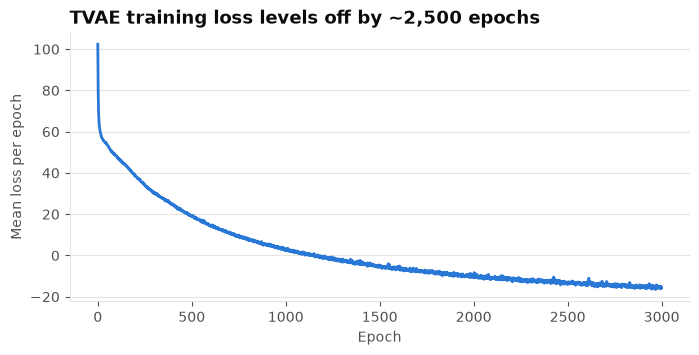

saved figures\01_tvae_training_loss.png


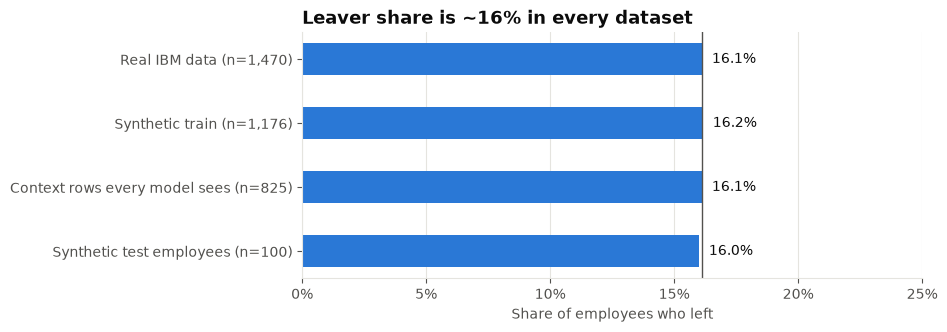

saved figures\02_class_balance.png


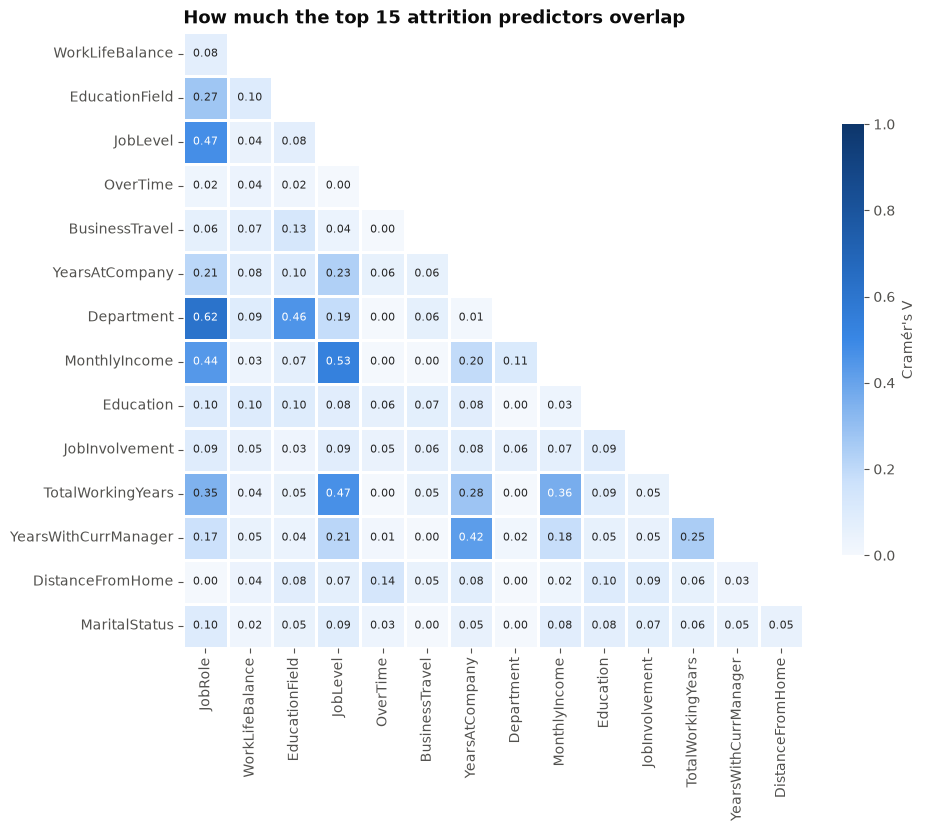

saved figures\03_feature_redundancy_heatmap.png


In [54]:
import math

import matplotlib.ticker as mticker

# FIGURES: every chart in one style, each saved as a PNG in figures/ (200 dpi, white background, video-ready)
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
INK, MUTED_INK, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4df", "#ffffff"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED_INK, "xtick.color": MUTED_INK, "ytick.color": MUTED_INK,
    "text.color": INK, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10, "legend.frameon": False,
})

# Colour follows the MODEL in every chart, never its rank. Baselines are grey; Jev takes the lead hue.
MODEL_COLORS = {
    "RF (neutral)": "#52514e", "RF (balanced, cost-aware reference)": "#9e9d98",
    "Jev": "#2a78d6", "Claude Sonnet 5": "#eb6834", "GPT-6 Sol": "#1baf7a",
    "Gemini 3.8 Flash": "#eda100", "gpt-oss 20B (local)": "#e87ba4",
}
DISPLAY_NAMES = {"RF (balanced, cost-aware reference)": "RF (balanced)"}
METRIC_COLORS = {"F2": "#2a78d6", "recall": "#eb6834", "precision": "#1baf7a"}
OUTCOME_COLORS = {"caught leavers": "#2a78d6", "missed leavers": "#eb6834", "false alarms": "#b5b4ae"}

def display_name(model_name):
    return DISPLAY_NAMES.get(model_name, model_name)

def style_value_axis(ax, axis="y"):
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def save_figure(fig, name):
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"saved {path}")

# --- Data-prep figures (re-rendered here in the shared style from the objects cells 3, 6 and 9 left in memory) ---

# 1. Generator training curve
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(loss_per_epoch.index, loss_per_epoch.values, color=MODEL_COLORS["Jev"], linewidth=2)
ax.set_title("TVAE training loss levels off by ~2,500 epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean loss per epoch")
style_value_axis(ax)
save_figure(fig, "01_tvae_training_loss")

# 2. Class balance sanity check: every set the models touch keeps the real leaver rate
real_leaver_rate = (real_dataset[TARGET] == "Yes").mean()
class_balance = pd.Series({
    f"Real IBM data (n={len(real_dataset):,})": real_leaver_rate,
    f"Synthetic train (n={len(synthetic_dataset_train_binned):,})": (synthetic_dataset_train_binned[TARGET] == "Yes").mean(),
    f"Context rows every model sees (n={len(context_rows)})": (context_rows[TARGET] == "Yes").mean(),
    f"Synthetic test employees (n={len(test_employees)})": (test_employees[TARGET] == "Yes").mean(),
})[::-1]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(class_balance.index, class_balance.values, height=0.5, color=MODEL_COLORS["Jev"])
for y, rate in enumerate(class_balance.values):
    ax.text(rate + 0.004, y, f"{rate:.1%}", va="center", color=INK)
ax.axvline(real_leaver_rate, color=MUTED_INK, linewidth=1)
ax.set_xlim(0, 0.25)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_title("Leaver share is ~16% in every dataset")
ax.set_xlabel("Share of employees who left")
style_value_axis(ax, "x")
save_figure(fig, "02_class_balance")

# 3. Feature redundancy heatmap (Cramér's V), lower triangle
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cramers_v_matrix.iloc[1:, :-1],
    mask=np.triu(np.ones((HEATMAP_TOP_N - 1, HEATMAP_TOP_N - 1), dtype=bool), k=1), cmap=sequential_blues,
    vmin=0, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=2, linecolor=SURFACE,
    cbar_kws={"label": "Cramér's V", "shrink": 0.7}, ax=ax,
)
ax.set_title(f"How much the top {HEATMAP_TOP_N} attrition predictors overlap")
save_figure(fig, "03_feature_redundancy_heatmap")

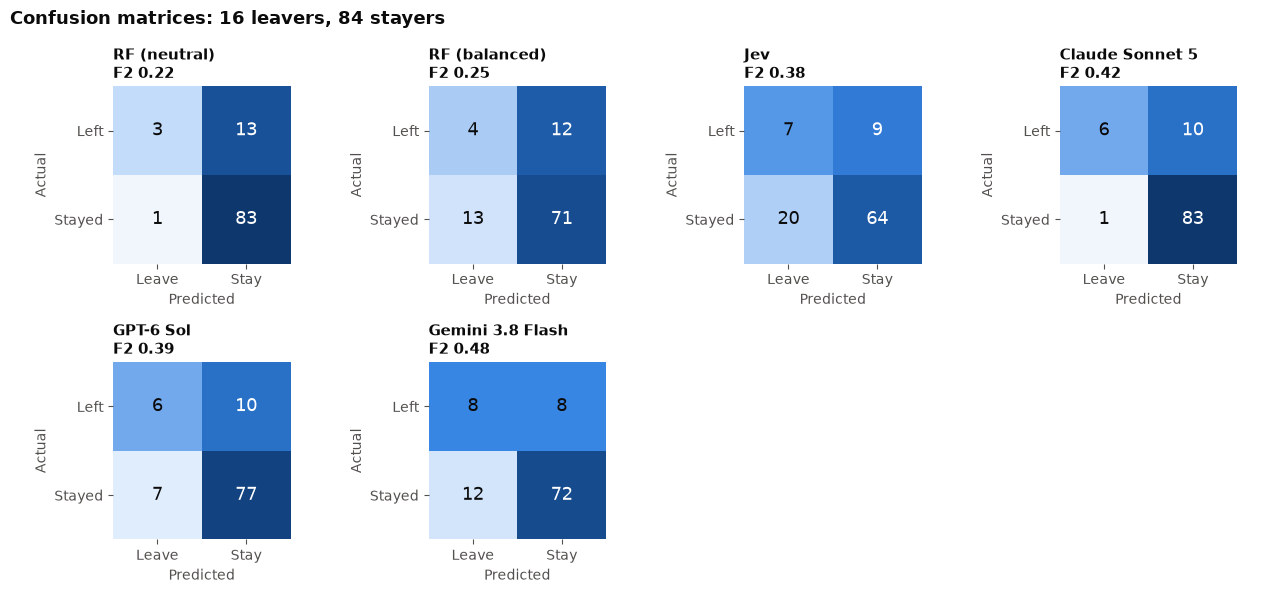

saved figures\04_confusion_matrices.png


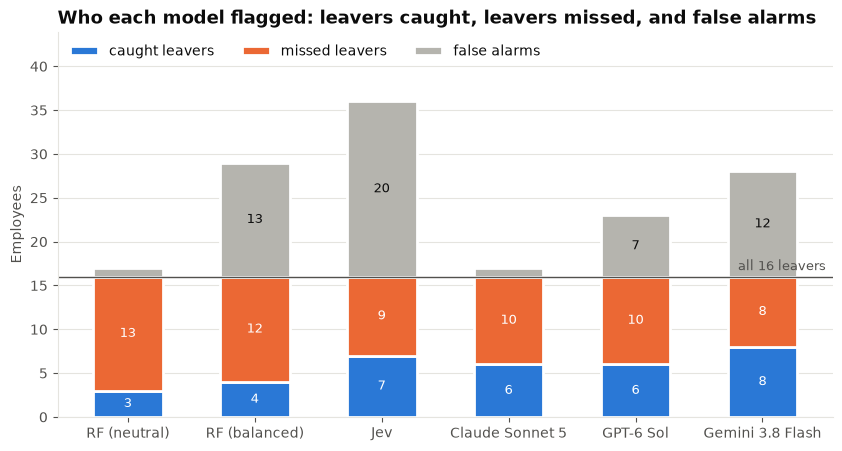

saved figures\05_caught_missed_false_alarms.png


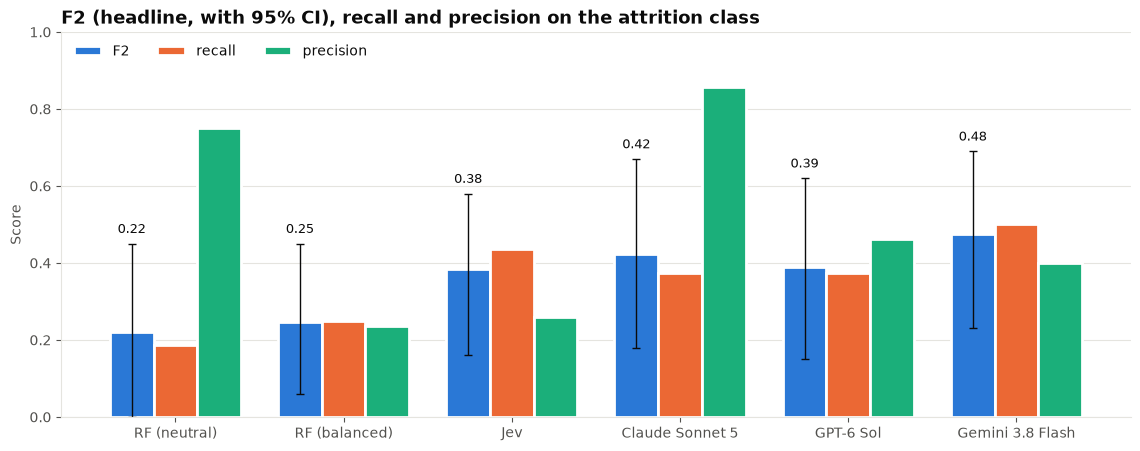

saved figures\06_f2_recall_precision.png


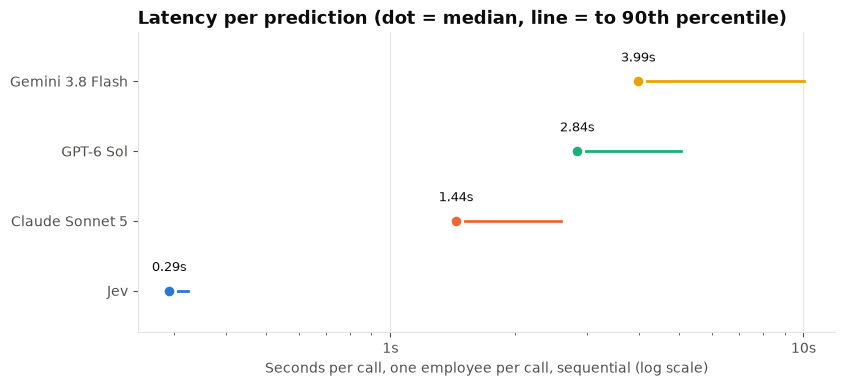

saved figures\07_latency_per_prediction.png


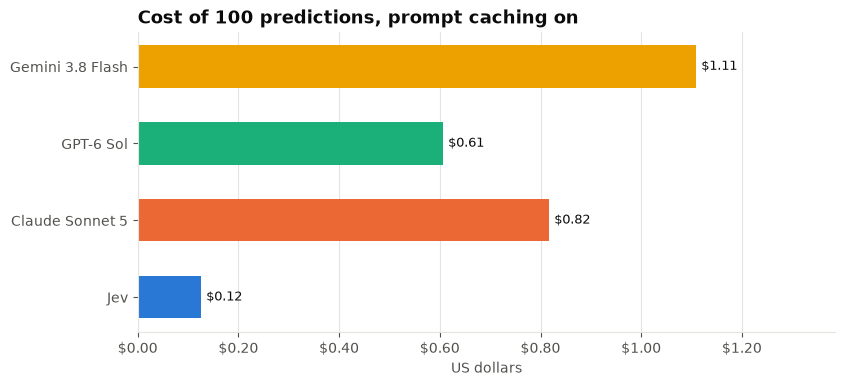

saved figures\08_cost_per_100_predictions.png


In [55]:
# --- Main results: every model on the SAME 100 synthetic test employees ---
MODEL_ORDER = [model for model in MODEL_COLORS if model in results_table.index]   # baselines first, fixed order
scores = results_table.loc[MODEL_ORDER]
leaver_count = int(scores["TP"].iloc[0] + scores["FN"].iloc[0])

# 4. Confusion matrix per model (colour = share of that ACTUAL row, so leaver and stayer rows read on one scale)
columns = 4
fig, axes = plt.subplots(math.ceil(len(MODEL_ORDER) / columns), columns, figsize=(3.2 * columns, 3.0 * math.ceil(len(MODEL_ORDER) / columns)))
for ax, model_name in zip(axes.flat, MODEL_ORDER):
    counts = np.array([[scores.loc[model_name, "TP"], scores.loc[model_name, "FN"]],
                       [scores.loc[model_name, "FP"], scores.loc[model_name, "TN"]]], dtype=int)
    row_share = counts / counts.sum(axis=1, keepdims=True)
    ax.imshow(row_share, cmap=sequential_blues, vmin=0, vmax=1)
    for (row, col), count in np.ndenumerate(counts):
        ax.text(col, row, str(count), ha="center", va="center", fontsize=13,
                color=SURFACE if row_share[row, col] > 0.55 else INK)
    ax.set_xticks([0, 1], ["Leave", "Stay"])
    ax.set_yticks([0, 1], ["Left", "Stayed"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{display_name(model_name)}\nF2 {scores.loc[model_name, 'F2']:.2f}", fontsize=11)
    ax.spines[:].set_visible(False)
for ax in list(axes.flat)[len(MODEL_ORDER):]:
    ax.axis("off")
fig.suptitle(f"Confusion matrices: {leaver_count} leavers, {len(test_employees) - leaver_count} stayers", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_figure(fig, "04_confusion_matrices")

# 5. Stacked column: caught + missed always = all leavers; false alarms stacked on top = the price of that recall
outcomes = pd.DataFrame({"caught leavers": scores["TP"], "missed leavers": scores["FN"], "false alarms": scores["FP"]}).astype(int)
fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(MODEL_ORDER))
bottom = np.zeros(len(MODEL_ORDER))
for outcome, color in OUTCOME_COLORS.items():
    ax.bar(x_positions, outcomes[outcome], bottom=bottom, width=0.55, color=color, edgecolor=SURFACE, linewidth=2, label=outcome)
    for x, (height, base) in enumerate(zip(outcomes[outcome], bottom)):
        if height >= 2:
            ax.text(x, base + height / 2, str(height), ha="center", va="center", fontsize=9,
                    color=SURFACE if outcome != "false alarms" else INK)
    bottom += outcomes[outcome].values
ax.axhline(leaver_count, color=MUTED_INK, linewidth=1)
ax.text(len(MODEL_ORDER) - 0.5, leaver_count + 0.4, f"all {leaver_count} leavers", ha="right", va="bottom", color=MUTED_INK, fontsize=9)
ax.set_xticks(x_positions, [display_name(model) for model in MODEL_ORDER])
ax.set_ylabel("Employees")
ax.set_ylim(0, bottom.max() * 1.22)   # headroom so the legend never sits on a column
ax.set_title("Who each model flagged: leavers caught, leavers missed, and false alarms")
ax.legend(loc="upper left", ncols=3)
style_value_axis(ax)
save_figure(fig, "05_caught_missed_false_alarms")

# 6. Grouped bars: F2 (headline, with 95% bootstrap CI) / recall / precision. A function, so the real-data test (12)
#    is drawn exactly the same way.
def plot_f2_recall_precision(metric_scores, title, figure_name):
    positions = np.arange(len(metric_scores))
    ci_bounds = metric_scores["F2 95% CI"].str.split("-", expand=True).astype(float)
    fig, ax = plt.subplots(figsize=(max(8, 2.3 * len(metric_scores)), 5))
    bar_width = 0.26
    for offset, (metric, color) in zip([-bar_width, 0, bar_width], METRIC_COLORS.items()):
        values = metric_scores[metric].astype(float).values
        ax.bar(positions + offset, values, width=bar_width, color=color, edgecolor=SURFACE, linewidth=2, label=metric)
        if metric == "F2":
            ax.errorbar(positions + offset, values, yerr=[values - ci_bounds[0].values, ci_bounds[1].values - values],
                        fmt="none", ecolor=INK, elinewidth=1, capsize=3)
            for x, value, upper in zip(positions + offset, values, ci_bounds[1].values):
                ax.text(x, upper + 0.02, f"{value:.2f}", ha="center", va="bottom", fontsize=9, color=INK)
    ax.set_xticks(positions, [display_name(model) for model in metric_scores.index])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend(loc="upper left", ncols=3)
    style_value_axis(ax)
    save_figure(fig, figure_name)

plot_f2_recall_precision(scores, "F2 (headline, with 95% CI), recall and precision on the attrition class", "06_f2_recall_precision")

# --- Speed and cost: API models only (the RF has no per-call cost or network latency) ---
efficiency_models = [model for model in MODEL_ORDER if model in efficiency_table.index]
efficiency = efficiency_table.loc[efficiency_models]

# 7. Latency per call: dot = median, line = up to p90. Log scale, since models differ by ~10-100x.
fig, ax = plt.subplots(figsize=(9, 0.6 * len(efficiency_models) + 1.5))
for y, model_name in enumerate(efficiency_models):
    median, p90 = efficiency.loc[model_name, ["median latency s", "p90 latency s"]].astype(float)
    ax.plot([median, p90], [y, y], color=MODEL_COLORS[model_name], linewidth=2)
    ax.scatter(median, y, s=80, color=MODEL_COLORS[model_name], edgecolor=SURFACE, linewidth=2, zorder=3)
    ax.text(median, y + 0.28, f"{median:.2f}s", ha="center", fontsize=9, color=INK)
ax.set_yticks(range(len(efficiency_models)), [display_name(model) for model in efficiency_models])
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{value:g}s"))
ax.set_ylim(-0.6, len(efficiency_models) - 0.3)
ax.set_title("Latency per prediction (dot = median, line = to 90th percentile)")
ax.set_xlabel("Seconds per call, one employee per call, sequential (log scale)")
style_value_axis(ax, "x")
save_figure(fig, "07_latency_per_prediction")

# 8. Cost for all 100 predictions (API list prices; the local model's hardware and power aren't counted)
costs = efficiency["total cost $"].astype(float)
fig, ax = plt.subplots(figsize=(9, 0.6 * len(efficiency_models) + 1.5))
ax.barh(range(len(efficiency_models)), costs.values, height=0.55, color=[MODEL_COLORS[model] for model in efficiency_models])
for y, (model_name, cost) in enumerate(costs.items()):
    label = "$0 API cost (local GPU)" if cost == 0 else f"${cost:.2f}"
    ax.text(cost + costs.max() * 0.01, y, label, va="center", fontsize=9, color=INK)
ax.set_yticks(range(len(efficiency_models)), [display_name(model) for model in efficiency_models])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"${value:.2f}"))
ax.set_xlim(0, costs.max() * 1.25)
ax.set_title(f"Cost of {len(test_employees)} predictions, prompt caching on")
ax.set_xlabel("US dollars")
style_value_axis(ax, "x")
save_figure(fig, "08_cost_per_100_predictions")

# 9. Throughput under parallelism: STUB for the Jev parallel-harness experiment (out of scope for this run)
def plot_throughput(parallel_runs):
    """parallel_runs: DataFrame with columns model, concurrency, predictions_per_second. Saves 09_throughput.png."""
    raise NotImplementedError("wire up once the parallel run exists")

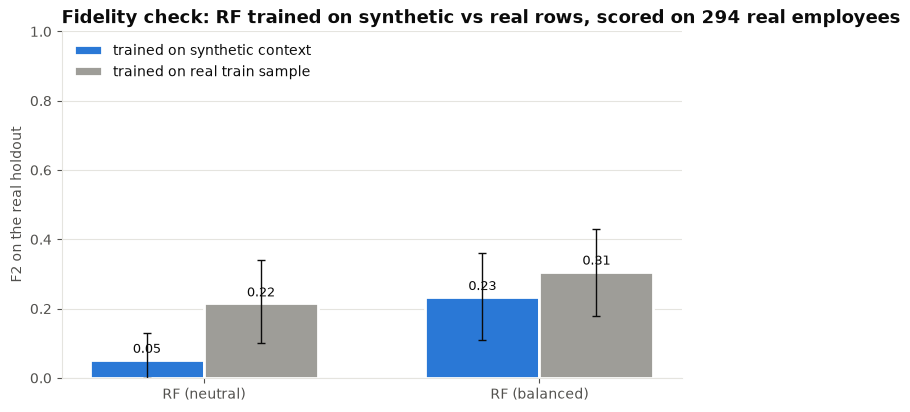

saved figures\10_fidelity_synthetic_vs_real.png


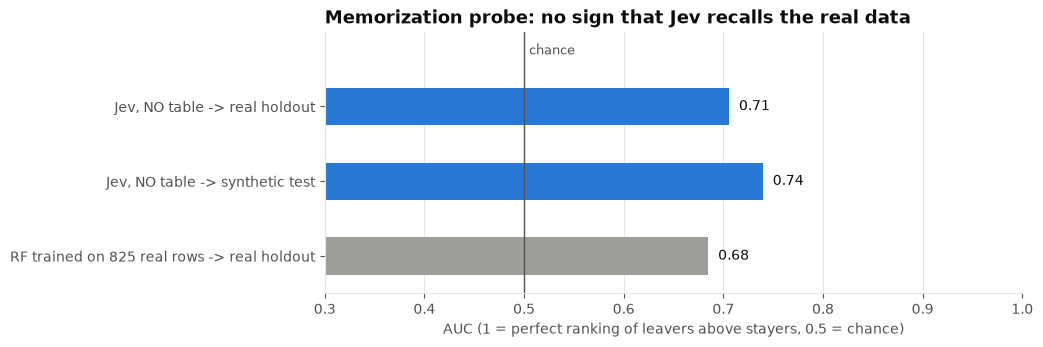

saved figures\11_memorization_probe.png


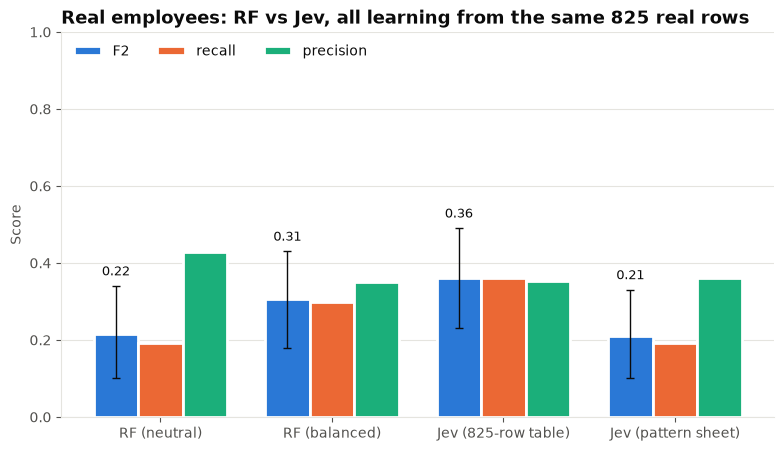

saved figures\12_real_data_rf_vs_jev.png


In [56]:
# --- Separate tests ---

# 10. Fidelity check: does synthetic training data carry the REAL signal? Same RF, scored on real employees.
fidelity = fidelity_table.reset_index()
fidelity.columns = ["rf", "trained on"] + list(fidelity.columns[2:])
rf_variants = list(dict.fromkeys(fidelity["rf"]))
training_sources = {"synthetic context": "#2a78d6", "real train sample": "#9e9d98"}
fig, ax = plt.subplots(figsize=(8, 4.5))
bar_width = 0.34
for offset, (source, color) in zip([-bar_width / 2, bar_width / 2], training_sources.items()):
    rows = fidelity[fidelity["trained on"] == source].set_index("rf").loc[rf_variants]
    values = rows["F2"].astype(float).values
    ci = rows["F2 95% CI"].str.split("-", expand=True).astype(float)
    positions = np.arange(len(rf_variants)) + offset
    ax.bar(positions, values, width=bar_width, color=color, edgecolor=SURFACE, linewidth=2, label=f"trained on {source}")
    ax.errorbar(positions, values, yerr=[values - ci[0].values, ci[1].values - values], fmt="none", ecolor=INK, elinewidth=1, capsize=3)
    for x, value in zip(positions, values):
        ax.text(x, value + 0.02, f"{value:.2f}", ha="center", fontsize=9, color=INK)
ax.set_xticks(range(len(rf_variants)), [display_name(rf) for rf in rf_variants])
ax.set_ylim(0, 1)
ax.set_ylabel("F2 on the real holdout")
ax.set_title(f"Fidelity check: RF trained on synthetic vs real rows, scored on {len(real_dataset_test_binned)} real employees")
ax.legend(loc="upper left")
style_value_axis(ax)
save_figure(fig, "10_fidelity_synthetic_vs_real")

# 11. Memorization probe: Jev with NO table ranks real and synthetic employees equally well -> no sign of recall
probe_auc = memorization_probe["AUC"].astype(float)
probe_colors = ["#2a78d6", "#2a78d6", "#9e9d98"]   # both Jev bars share Jev's hue; the RF reference is grey
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(range(len(probe_auc)), probe_auc.values, height=0.5, color=probe_colors)
for y, auc in enumerate(probe_auc.values):
    ax.text(auc + 0.01, y, f"{auc:.2f}", va="center", fontsize=10, color=INK)
ax.axvline(0.5, color=MUTED_INK, linewidth=1)
ax.set_yticks(range(len(probe_auc)), probe_auc.index)
ax.set_ylim(len(probe_auc) - 0.5, -1.0)   # inverted, with a strip on top for the "chance" label
ax.text(0.505, -0.75, "chance", ha="left", va="center", fontsize=9, color=MUTED_INK)
ax.set_xlim(0.3, 1)
ax.set_title("Memorization probe: no sign that Jev recalls the real data")
ax.set_xlabel("AUC (1 = perfect ranking of leavers above stayers, 0.5 = chance)")
style_value_axis(ax, "x")
save_figure(fig, "11_memorization_probe")

# 12. Real data, like for like: every contender learned from the same 825 real rows, scored on the real holdout
plot_f2_recall_precision(
    real_data_results.loc[["RF (neutral)", "RF (balanced, cost-aware reference)", "Jev (825-row table)", "Jev (pattern sheet)"]],
    f"Real employees: RF vs Jev, all learning from the same {len(real_train_sample)} real rows",
    "12_real_data_rf_vs_jev",
)